
# Pipeline A — Interactive Walkthrough

Runs the predictive semantic cache invalidation pipeline (`parser -> embedder ->
extractor -> predictor -> evaluator -> visualizer`) one stage at a time, timing
every stage and sub-step, and showing intermediate results as it goes.

This mirrors the orchestration in `run_experiment.py`'s `Experiment` class, but
each stage is its own cell so you can inspect, re-run, or tweak any single part
without re-running the whole pipeline. It skips `run_experiment.py`'s
per-commit-pair diagnostic JSON dumping (that's for post-hoc debugging, not
needed to see how the pipeline behaves here).

Includes the same `label_source` switch as `run_experiment.py`: `"cosine_threshold"`
(the original raw-cosine-drift label) or `"leave_one_out"` (the rank-displacement +
Wilcoxon ground truth from `src/embedder/ground_truth.py` — see
`docs/ground_truth_method_comparison.md`), plus the AST-canonicalization fix so a
pure rename doesn't count as a semantic change.

**How to use:** set the config in the next cell, then run all cells top to
bottom. The last section shows a full timing breakdown (which stage/sub-step
took the most time) and a table of every result produced along the way.


In [1]:
# =============================================================================
# SETTINGS — everything you'd normally pass as CLI flags / settings.json
# =============================================================================

CONFIG = {
    "repo_url":        "https://github.com/psf/black.git",
    "workspace_dir":   "workspace",
    "model_name":      "sentence-transformers/all-MiniLM-L6-v2",
    "device":          "cuda",  # "auto" (CUDA if available, else CPU), "cpu", "cuda", "cuda:0", ...

    "num_commits":     150,    # number of sampled commits to analyze
    "commit_stride":   15,     # step size between sampled commits
    "train_ratio":     0.7,    # fraction of commits used for training

    "threshold":       0.05,   # drift threshold for classification (ignored when threshold_mode="dynamic")
    "threshold_mode":  "dynamic",   # "fixed" or "dynamic" (85th percentile of train drift)

    "clean_mode":       False,  # strip comments/docstrings before embedding
    "context_chunking": True,   # splice dependency stubs into embedded source

    "k_values":          [5, 10],   # Recall@K values to evaluate
    "fixed_hop_values":  [1, 2],    # K values for the fixed-hop baseline

    # Predictor training label. "cosine_threshold" (default, original behavior):
    # raw cosine drift binarized by threshold/threshold_mode above. "leave_one_out":
    # Y_i from the leave-one-out rank-displacement + Wilcoxon significance ground
    # truth in src/embedder/ground_truth.py (see docs/ground_truth_method_comparison.md).
    # Both use the exact same features/training loop — only this line changes which
    # label the predictor is trained against.
    "label_source":              "leave_one_out",  # "cosine_threshold" or "leave_one_out"
    "ground_truth_top_k":        20,    # Top-K window for leave_one_out (ignored otherwise)
    "ground_truth_queries_path": None,  # override path; default: src/benchmarking/data/curated_queries.json
}
assert CONFIG["label_source"] in ("cosine_threshold", "leave_one_out"), \
    f"Unknown label_source: {CONFIG['label_source']!r}"

RANDOM_SEED = 42

## Setup — imports, timing infrastructure, and the execution plan

In [2]:
import sys, os, time, json, logging, warnings
from pathlib import Path
from contextlib import contextmanager
from typing import Dict, List, Set, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from parser.git_helper import GitHelper
from parser.tree_sitter_repo_parser import TreeSitterRepoParser, Entity
from embedder.embedding_manager import EmbeddingManager
from extractor.feature_extractor import FeatureExtractor
from extractor.gtd import GraphTransitionDescriptor
from extractor.rsd import RepositoryStateDescriptor
from predictor.predictor import DriftPredictor, train_test_split_temporal, positive_class_proba
from embedder.ground_truth import (
    binarize_ground_truth,
    compute_leave_one_out_scores,
    load_ground_truth_queries,
)
from evaluator.evaluator import (
    Evaluator, BaselineAChangedOnly, BaselineBFullReindex, BaselineCFixedHop,
    BaselineDPageRankPropagation, PredictiveStrategy, WeightedBFSDecayStrategy,
)
from visualizer.visualize import Visualizer

logging.basicConfig(level=logging.WARNING)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

# Recall@K column names derived from CONFIG["k_values"] — never hardcode
# "recall_at_10" downstream, since k_values is meant to be changed above.
RECALL_COLS = [f"recall_at_{k}" for k in CONFIG["k_values"]]
PRIMARY_RECALL_COL = f"recall_at_{max(CONFIG['k_values'])}"


# ---- Timing infrastructure -------------------------------------------------
TIMINGS: List[dict] = []  # rows of {stage, substage, seconds}


@contextmanager
def timed(stage: str, substage: str = "_total"):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        TIMINGS.append({"stage": stage, "substage": substage,
                         "seconds": time.perf_counter() - t0})


def timing_table(group_cols=("stage", "substage")) -> pd.DataFrame:
    if not TIMINGS:
        return pd.DataFrame(columns=[*group_cols, "calls", "total_seconds", "mean_seconds"])
    df = pd.DataFrame(TIMINGS)
    g = df.groupby(list(group_cols), sort=False)["seconds"].agg(["count", "sum", "mean"]).reset_index()
    g.columns = [*group_cols, "calls", "total_seconds", "mean_seconds"]
    return g.sort_values("total_seconds", ascending=False).reset_index(drop=True)


# ---- The plan ---------------------------------------------------------------
PLAN = [
    ("0. Setup",              "Clone repo, construct embedder/predictor/visualizer"),
    ("1. Harvest commits",    "Read commit history, pick sampled commits at the given stride"),
    ("2. Parse & embed",      "Per sampled commit: checkout, Tree-sitter parse, batch-embed entities"),
    ("3. Drift & features",   "Per consecutive commit pair: compute drift, GTD, modified entities, features"),
    ("4. Train predictor",    "Fit the drift classifier on training commit pairs, evaluate on held-out split"),
    ("5. Evaluate strategies","Per test commit pair: predict drift, score every cache-invalidation strategy"),
    ("6. Visualize",          "Render plots + summary report from everything collected above"),
]
print("Execution plan:")
for i, (stage, desc) in enumerate(PLAN):
    print(f"  {stage:<24s} {desc}")

Execution plan:
  0. Setup                 Clone repo, construct embedder/predictor/visualizer
  1. Harvest commits       Read commit history, pick sampled commits at the given stride
  2. Parse & embed         Per sampled commit: checkout, Tree-sitter parse, batch-embed entities
  3. Drift & features      Per consecutive commit pair: compute drift, GTD, modified entities, features
  4. Train predictor       Fit the drift classifier on training commit pairs, evaluate on held-out split
  5. Evaluate strategies   Per test commit pair: predict drift, score every cache-invalidation strategy
  6. Visualize             Render plots + summary report from everything collected above


## Stage 0 — Setup: clone repository, construct pipeline components

In [3]:
with timed("0_setup", "clone_repo"):
    repo_path = PROJECT_ROOT / CONFIG["workspace_dir"] / "black"
    git_helper = GitHelper(str(repo_path))
    ok = git_helper.clone_repo(CONFIG["repo_url"], str(repo_path))
    assert ok, "Failed to clone repository"

with timed("0_setup", "construct_components"):
    embedding_manager = EmbeddingManager(model_name=CONFIG["model_name"], clean_mode=CONFIG["clean_mode"],
                                          device=CONFIG["device"])
    predictor = DriftPredictor(model_type="random_forest", task_type="classification",
                                threshold=CONFIG["threshold"])
    rsd = RepositoryStateDescriptor()

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    results_dir = PROJECT_ROOT / "results" / f"notebook_{timestamp}"
    results_dir.mkdir(parents=True, exist_ok=True)
    visualizer = Visualizer(str(results_dir))

assert not (CONFIG["label_source"] == "leave_one_out" and predictor.task_type != "classification"), (
    "label_source='leave_one_out' produces a binary Y_i label, which is not a valid "
    "regression target. Use task_type='classification', or switch to label_source='cosine_threshold'."
)

# Ground-truth queries are fixed for the whole run (independent of any commit
# pair) — load and embed once here, not per commit pair. Query independence is
# load-bearing: this MUST come from curated_queries.json (hand-authored, fixed
# target_entity_id), never from generate_queries() below, which selects
# entities by the model's own drift score and builds text from the target's
# own docstring — see src/embedder/ground_truth.py's module docstring.
with timed("0_setup", "load_ground_truth_queries"):
    if CONFIG["label_source"] == "leave_one_out":
        ground_truth_queries = load_ground_truth_queries(CONFIG["ground_truth_queries_path"])
        ground_truth_query_embeddings = {
            q.query_id: embedding_manager.generate_embedding(q.query_id, q.query_text)
            for q in ground_truth_queries
        }
        print(f"Loaded {len(ground_truth_queries)} curated ground-truth queries.")
        if not ground_truth_queries:
            print("WARNING: curated query set is empty — leave_one_out will produce no labels at all.")
    else:
        ground_truth_queries, ground_truth_query_embeddings = [], {}

print(f"Repo ready at: {repo_path}")
print(f"Results will be saved under: {results_dir}")
print(f"Label source: {CONFIG['label_source']}")
print(f"CUDA available: {torch.cuda.is_available()}"
      + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"Embedding device resolved to: {embedding_manager.device}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 30 curated ground-truth queries.
Repo ready at: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\workspace\black
Results will be saved under: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\results\notebook_20260912_222921
Label source: leave_one_out
CUDA available: True  (NVIDIA GeForce RTX 3050 Laptop GPU)
Embedding device resolved to: cuda


## Stage 1 — Harvest commit history

In [4]:
with timed("1_harvest", "get_commit_history"):
    raw_commit_count = CONFIG["num_commits"] * CONFIG["commit_stride"]
    all_commits = git_helper.get_commit_history(count=raw_commit_count)

assert len(all_commits) >= CONFIG["commit_stride"] + 1, (
    f"Not enough commits ({len(all_commits)}) for stride={CONFIG['commit_stride']}"
)

sampled_commits = all_commits[::CONFIG["commit_stride"]][:CONFIG["num_commits"]]
assert len(sampled_commits) >= 2, "Need at least 2 sampled commits"

print(f"Raw commits fetched: {len(all_commits)}")
print(f"Sampled commits ({len(sampled_commits)}) at stride={CONFIG['commit_stride']}:")
for c in sampled_commits:
    print(f"  {c[:10]}")

Raw commits fetched: 2110
Sampled commits (141) at stride=15:
  e74117f172
  c85cb48ec2
  c90cf42d7c
  d1e0d79e38
  7914a5b0a2
  1f18cd2ba5
  10bb45c35e
  ba61bfe386
  63da5d088c
  ecdbf085a7
  2104b7cdcb
  6a9d09cd44
  c86fb36232
  1885721182
  e196180a0d
  0da97417ed
  1dadeef47a
  5070a24121
  fd9bd07fe5
  51756a405c
  dbe26161fa
  26b92e66ac
  de702bcdf1
  2cf125a97c
  2dfa69bb7f
  9c8caecdd6
  883689366c
  08f1cdd00b
  a4b5c085a3
  32eed7d188
  7546ed292c
  118b612059
  cfa2557df0
  acafdcb594
  3b96abdb80
  957ba24bb6
  1fbf7251cc
  720dd415f7
  7ae084aaa1
  7b11f04d54
  394edc3887
  b65af236cf
  31f4105731
  1ab87a3f67
  c3589afa3d
  7e4c6bf71f
  68a3c75eb2
  89c87d22e7
  45c98cf150
  d0b3d38493
  d3cc63316b
  149b38d674
  2fc1dfca96
  ceeb1d9a2e
  25c1b6dff7
  172c0a78fa
  6c3f818185
  60de5bbc32
  988c686d31
  a23f521fee
  cac18293d5
  c702588daa
  6d0bdc2f38
  0a833b4b14
  682077c15e
  5316836393
  f933e8a838
  0b9b7dbdab
  199e3eb76b
  a9eab85f22
  8d8b3d1805
  65abd1006b
  

## Stage 2 — Parse & embed each sampled commit

For every sampled commit: checkout, rebuild the Tree-sitter dependency graph,
and batch-generate embeddings for every entity (optionally splicing in
call-graph context per `context_chunking`).

In [5]:
def extract_signature(entity: Entity) -> str:
    # Grab just the def/class header line(s) from an entity's source.
    lines = entity.source_code.splitlines()
    def_idx = next((i for i, l in enumerate(lines)
                     if l.strip().startswith(("def ", "async def ", "class "))), -1)
    if def_idx == -1:
        return f"def {entity.entity_id.split('::')[-1]}()"
    sig_lines = []
    for i in range(def_idx, len(lines)):
        sig_lines.append(lines[i])
        if lines[i].split('#')[0].rstrip().endswith(':'):
            return "\n".join(sig_lines)
    return lines[def_idx]


def contextual_source(entity: Entity, repo_parser: TreeSitterRepoParser) -> str:
    # Entity source + one-hop dependency stubs, when context_chunking is on.
    source = entity.source_code
    if not CONFIG["context_chunking"]:
        return source

    deps = {d for d in repo_parser.get_dependencies(entity.entity_id, max_hops=1)
            if d != entity.entity_id}
    if not deps:
        return source

    stubs = []
    for dep_id in sorted(deps):
        dep = repo_parser.get_entity(dep_id)
        if not dep:
            continue
        sig = extract_signature(dep).strip()
        if not sig.endswith(':'):
            sig += ':'
        body_lines = [l.strip() for l in dep.source_code.split('\n')
                      if l.strip() and not l.strip().startswith(('def ', 'class ', '@'))]
        first_line = (body_lines[0] if body_lines else 'pass')[:120]
        stubs.append(f"{sig}\n    # Context: {first_line}\n    pass")

    return source + "\n\n# Call Graph Context\n" + "\n\n".join(stubs) if stubs else source


parsers_history: Dict[str, TreeSitterRepoParser] = {}
embeddings_history: Dict[str, Dict[str, np.ndarray]] = {}
commit_stats = []

for i, commit in enumerate(sampled_commits):
    print(f"[{i+1}/{len(sampled_commits)}] {commit[:10]}", end="  ")

    with timed("2_parse_embed", "checkout"):
        ok = git_helper.checkout_commit(commit)
    if not ok:
        print("checkout FAILED, skipping")
        continue

    with timed("2_parse_embed", "parse"):
        repo_parser = TreeSitterRepoParser(str(repo_path))
        repo_parser.parse_directory(str(repo_path))
        parsers_history[commit] = repo_parser

    entities = repo_parser.get_all_entities()
    entity_sources = {e.entity_id: contextual_source(e, repo_parser) for e in entities}

    with timed("2_parse_embed", "embed"):
        embeddings = embedding_manager.generate_embeddings_batch(entity_sources) if entity_sources else {}
    embeddings_history[commit] = embeddings

    with timed("2_parse_embed", "rsd_add_commit"):
        rsd.add_commit(commit_hash=commit, repo_parser=repo_parser, embeddings=embeddings,
                        modification_history={}, previous_drifts={},
                        commit_index=i, total_commits=len(sampled_commits))

    print(f"entities={len(entities)}  embeddings={len(embeddings)}")
    commit_stats.append({"commit": commit[:10], "n_entities": len(entities), "n_embeddings": len(embeddings)})

pd.DataFrame(commit_stats)

[1/141] e74117f172  

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

entities=228  embeddings=228
[2/141] c85cb48ec2  

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

entities=228  embeddings=228
[3/141] c90cf42d7c  

...

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=678  embeddings=678
[141/141] 2fd75b04ff  

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=678  embeddings=678


,commit,n_entities,n_embeddings
0,e74117f172,228,228
1,c85cb48ec2,228,228
2,c90cf42d7c,232,232
3,d1e0d79e38,233,233
4,7914a5b0a2,235,235
...,...,...,...
136,cafb0f742e,667,667
137,f7354342e4,672,672
138,05f0a8ce1f,677,677
139,58c5ac8030,678,678


## Stage 3 — Compute drift & extract features for each consecutive commit pair

For each `(commit_a, commit_b)` pair: cosine drift between embeddings, the
Graph Transition Descriptor, which entities were *semantically* modified (an
AST-canonicalization filter alpha-renames local variables/parameters before
comparing, so a pure rename doesn't count as a change — only whitespace,
comments, and now identifier renames are excluded; call targets, attributes,
and docstrings still count, since a docstring is exactly what a retrieval
embedding represents), and the full feature matrix fed to the predictor. When
`label_source="leave_one_out"`, this stage also computes the leave-one-out
rank-displacement + Wilcoxon ground-truth label per entity.

In [6]:
import ast, re as _re

_CANONICALIZE_EXEMPT_NAMES = {"self", "cls"}


class _LocalNameCollector(ast.NodeVisitor):
    # Collects local bindings (assignment targets, function parameters) in
    # first-appearance order, so they can be alpha-renamed to canonical
    # placeholders before comparing two versions of an entity's source.
    # Deliberately does NOT touch call targets, attributes, imports, or
    # string/docstring literals.
    def __init__(self):
        self.order: List[str] = []
        self._seen: Set[str] = set()

    def _register(self, name: str) -> None:
        if name in _CANONICALIZE_EXEMPT_NAMES or name in self._seen:
            return
        self._seen.add(name)
        self.order.append(name)

    def visit_Name(self, node):
        if isinstance(node.ctx, ast.Store):
            self._register(node.id)
        self.generic_visit(node)

    def visit_arg(self, node):
        self._register(node.arg)
        self.generic_visit(node)


class _LocalNameRenamer(ast.NodeTransformer):
    def __init__(self, mapping: Dict[str, str]):
        self.mapping = mapping

    def visit_Name(self, node):
        if node.id in self.mapping:
            node.id = self.mapping[node.id]
        return node

    def visit_arg(self, node):
        if node.arg in self.mapping:
            node.arg = self.mapping[node.arg]
        return node


def _canonicalize_local_names(tree):
    collector = _LocalNameCollector()
    collector.visit(tree)
    mapping = {name: f"_v{i}" for i, name in enumerate(collector.order)}
    return _LocalNameRenamer(mapping).visit(tree)


def normalize_source(code_str: str) -> str:
    # AST-canonicalize source (alpha-rename locals) so cosmetic-only diffs
    # AND pure renames don't count as changes.
    try:
        tree = ast.parse(code_str)
        tree = _canonicalize_local_names(tree)
        return ast.dump(tree, annotate_fields=False)
    except Exception:
        cleaned = _re.sub(r'#.*', '', code_str)
        return " ".join(cleaned.split())


modification_history: Dict[str, List[str]] = {}
previous_drifts: Dict[str, float] = {}
gtd_history: Dict[Tuple[str, str], GraphTransitionDescriptor] = {}
drifts_history: Dict[Tuple[str, str], Dict[str, float]] = {}
ground_truth_history: Dict[Tuple[str, str], Dict[str, float]] = {}
features_history: Dict[Tuple[str, str], pd.DataFrame] = {}
pair_stats = []

for i in range(1, len(sampled_commits)):
    commit_a, commit_b = sampled_commits[i - 1], sampled_commits[i]
    if commit_a not in embeddings_history or commit_b not in embeddings_history:
        continue
    emb_a, emb_b = embeddings_history[commit_a], embeddings_history[commit_b]
    if not emb_a or not emb_b:
        continue

    repo_parser_b = parsers_history[commit_b]

    with timed("3_drift_features", "compute_drift"):
        drifts = embedding_manager.compute_all_drifts(emb_a, emb_b)

    if CONFIG["label_source"] == "leave_one_out":
        with timed("3_drift_features", "leave_one_out_ground_truth"):
            if ground_truth_queries:
                loo_results = compute_leave_one_out_scores(
                    embeddings_before=emb_a, embeddings_after=emb_b,
                    queries=ground_truth_queries, query_embeddings=ground_truth_query_embeddings,
                    top_k=CONFIG["ground_truth_top_k"],
                )
                gt_labels = binarize_ground_truth(loo_results)
                ground_truth_history[(commit_a, commit_b)] = {
                    eid: float(label.label) for eid, label in gt_labels.items()
                }
            else:
                ground_truth_history[(commit_a, commit_b)] = {}

    with timed("3_drift_features", "gtd"):
        gtd = GraphTransitionDescriptor()
        gtd.compute(parser_a=parsers_history.get(commit_a), parser_b=repo_parser_b, drifts=drifts)
        gtd_history[(commit_a, commit_b)] = gtd

    with timed("3_drift_features", "modified_entities"):
        modified_files = git_helper.get_modified_files(commit_a, commit_b)
        candidate_modified = {
            eid for eid in drifts
            if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
        }
        for e in repo_parser_b.get_all_entities():
            if e.file_path in modified_files:
                candidate_modified.add(e.entity_id)

        parser_prev = parsers_history.get(commit_a)
        modified_entities = set()
        for eid in candidate_modified:
            prev_e = parser_prev.entities.get(eid) if parser_prev else None
            curr_e = repo_parser_b.entities.get(eid)
            if not prev_e or not curr_e:
                modified_entities.add(eid)
            elif normalize_source(prev_e.source_code) != normalize_source(curr_e.source_code):
                modified_entities.add(eid)

    entity_ids = [eid for eid in drifts if eid in repo_parser_b.get_graph()]
    if not entity_ids:
        continue

    with timed("3_drift_features", "extract_features"):
        feature_extractor = FeatureExtractor(repo_parser_b)
        features_df = feature_extractor.extract_features_batch(
            entity_ids, commit_a, commit_b, modified_entities,
            modification_history, previous_drifts, git_helper, gtd=gtd,
        )

    for eid in modified_entities:
        feature_extractor.update_modification_history(eid, commit_b, modification_history)
    previous_drifts.update(drifts)

    drifts_history[(commit_a, commit_b)] = drifts
    features_history[(commit_a, commit_b)] = features_df

    gt_labels_this_pair = ground_truth_history.get((commit_a, commit_b), {})
    pair_stats.append({
        "pair": f"{commit_a[:8]}->{commit_b[:8]}",
        "n_entities": len(drifts),
        "n_modified": len(modified_entities),
        "mean_drift": float(np.mean(list(drifts.values()))) if drifts else 0.0,
        **({"leave_one_out_positive_rate":
                (sum(gt_labels_this_pair.values()) / len(gt_labels_this_pair)) if gt_labels_this_pair else 0.0}
           if CONFIG["label_source"] == "leave_one_out" else {}),
    })
    print(f"{commit_a[:8]}->{commit_b[:8]}  entities={len(drifts)}  modified={len(modified_entities)}")

pd.DataFrame(pair_stats)

e74117f1->c85cb48e  entities=228  modified=6


c85cb48e->c90cf42d  entities=228  modified=22


c90cf42d->d1e0d79e  entities=231  modified=23


d1e0d79e->7914a5b0  entities=232  modified=15


7914a5b0->1f18cd2b  entities=235  modified=37


...

93638880->cafb0f74  entities=664  modified=32


cafb0f74->f7354342  entities=666  modified=13


f7354342->05f0a8ce  entities=670  modified=24


05f0a8ce->58c5ac80  entities=676  modified=141
58c5ac80->2fd75b04  entities=677  modified=14


,pair,n_entities,n_modified,mean_drift,leave_one_out_positive_rate
0,e74117f1->c85cb48e,228,6,0.000921,0.0
1,c85cb48e->c90cf42d,228,22,0.001707,0.0
2,c90cf42d->d1e0d79e,231,23,0.003396,0.0
3,d1e0d79e->7914a5b0,232,15,0.001384,0.0
4,7914a5b0->1f18cd2b,235,37,0.007973,0.0
...,...,...,...,...,...
135,93638880->cafb0f74,664,32,0.001080,0.0
136,cafb0f74->f7354342,666,13,0.000059,0.0
137,f7354342->05f0a8ce,670,24,0.000958,0.0
138,05f0a8ce->58c5ac80,676,141,0.002664,0.0


## Finalize RSD & chronological train/test split

In [7]:
with timed("3_drift_features", "finalize_rsd_split"):
    rsd.build_all_rsds()
    split_idx = max(1, int(len(sampled_commits) * CONFIG["train_ratio"]))
    train_commits = sampled_commits[:split_idx]
    test_commits = sampled_commits[split_idx:]

print(f"Train commits: {len(train_commits)}   Test commits: {len(test_commits)}")
print()
print(rsd.summary_table())

Train commits: 98   Test commits: 43

Commit      S       T       M       C       E     
--------------------------------------------------
e74117f1    0.3380  0.4643  0.0026  0.2939  0.0004
c85cb48e    0.3381  0.4643  0.0026  0.2940  0.0004
c90cf42d    0.3394  0.4586  0.0029  0.2946  0.0004
d1e0d79e    0.3431  0.4572  0.0030  0.2933  0.0004
7914a5b0    0.3414  0.4515  0.0028  0.2902  0.0004
1f18cd2b    0.3476  0.3902  0.0021  0.2497  0.0004
10bb45c3    0.3475  0.3871  0.0022  0.2472  0.0004
ba61bfe3    0.3559  0.3848  0.0017  0.2620  0.0004
63da5d08    0.3593  0.3864  0.0025  0.2680  0.0005
ecdbf085    0.3594  0.3851  0.0020  0.2657  0.0005
2104b7cd    0.3628  0.3933  0.0023  0.2847  0.0005
6a9d09cd    0.3644  0.3811  0.0016  0.2917  0.0005
c86fb362    0.3641  0.3784  0.0018  0.2891  0.0005
18857211    0.3661  0.3802  0.0019  0.2948  0.0005
e196180a    0.3677  0.3835  0.0019  0.2965  0.0005
0da97417    0.3689  0.3826  0.0022  0.2993  0.0005
1dadeef4    0.3721  0.3870  0.0017  0.3079  

## Stage 4 — Train the drift predictor

In [8]:
# Same label-source switch as run_experiment.py's train_model(): both dicts
# are entity_id -> float, so everything below is label-source-agnostic.
label_history = ground_truth_history if CONFIG["label_source"] == "leave_one_out" else drifts_history

with timed("4_train", "combine_training_data"):
    all_features, all_labels = [], {}
    for i in range(1, len(train_commits)):
        key = (train_commits[i - 1], train_commits[i])
        if key not in features_history or key not in label_history or not label_history[key]:
            continue
        prefix = f"{key[0][:8]}_{key[1][:8]}"
        fdf = features_history[key].copy()
        fdf.index = [f"{prefix}::{eid}" for eid in fdf.index]
        all_features.append(fdf)
        all_labels.update({f"{prefix}::{eid}": v for eid, v in label_history[key].items()})

    assert all_features, (
        "No training data — widen num_commits/commit_stride"
        + (" (leave_one_out produced no labels for any training pair — check curated_queries.json "
           "target coverage against this repo's entities)" if CONFIG["label_source"] == "leave_one_out" else "")
    )
    combined_features = pd.concat(all_features, ignore_index=False)
    combined_features = combined_features[~combined_features.index.duplicated(keep="first")]

threshold = CONFIG["threshold"]
if CONFIG["label_source"] == "leave_one_out":
    # Y_i is already binary (0.0/1.0) — a percentile-based dynamic threshold
    # would be meaningless here. 0.5 cleanly separates the two label values.
    threshold = 0.5
    predictor.threshold = threshold
    positive_rate = sum(all_labels.values()) / len(all_labels) if all_labels else 0.0
    print(f"leave_one_out labels: {sum(all_labels.values()):.0f}/{len(all_labels)} "
          f"({positive_rate:.1%}) positive across combined training data.")
elif CONFIG["threshold_mode"] == "dynamic":
    # Most entities in any given commit pair are untouched (directly or via
    # context) and have exactly-zero drift; including them in the percentile
    # collapses the threshold to ~0 regardless of the percentile chosen. Take
    # the percentile over entities that actually drifted at all instead.
    vals = [v for v in all_labels.values() if not np.isnan(v)]
    nonzero_vals = [v for v in vals if v > 1e-9]
    if nonzero_vals:
        threshold = float(np.percentile(nonzero_vals, 85))
        predictor.threshold = threshold
        print(f"Dynamic threshold -> {threshold:.4f} (85th percentile of nonzero training drift, "
              f"{len(nonzero_vals)}/{len(vals)} rows had any drift)")
    elif vals:
        print(f"All {len(vals)} training drift values are ~zero; "
              f"keeping configured threshold {threshold:.4f} instead of a degenerate dynamic one")

with timed("4_train", "prepare_and_split"):
    predictor.prepare_data(combined_features, all_labels)
    X_train, X_test, y_train, y_test = train_test_split_temporal(
        combined_features, all_labels, train_ratio=CONFIG["train_ratio"]
    )

with timed("4_train", "fit"):
    train_metrics = predictor.train(X_train, y_train)

with timed("4_train", "evaluate_holdout"):
    test_metrics = predictor.evaluate(X_test, y_test)

with timed("4_train", "save_model"):
    model_path = results_dir / "drift_predictor.pkl"
    predictor.save(str(model_path))

print(f"Trained on {len(combined_features)} entities ({len(X_train)} train / {len(X_test)} test rows)")
pd.DataFrame([{"split": "train", **train_metrics}, {"split": "test", **test_metrics}])

leave_one_out labels: 0/38502 (0.0%) positive across combined training data.
Trained on 38502 entities (22741 train / 15761 test rows)


,split,train_accuracy,train_f1,train_precision,train_recall,test_accuracy,test_f1,test_precision,test_recall,test_pr_auc
0,train,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,test,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0


## Stage 5 — Evaluate cache-invalidation strategies

For each test commit pair: predict drift with the trained model, generate a
handful of synthetic retrieval queries, then score every invalidation
strategy (baselines + the predictive one) individually so their timings show
up separately in the final summary.

In [9]:
STRATEGIES = {
    "baseline_a_changed_only":      lambda: BaselineAChangedOnly(),
    "baseline_b_full_reindex":      lambda: BaselineBFullReindex(),
    "baseline_c_fixed_hop_k1":      lambda: BaselineCFixedHop(k=1),
    "baseline_c_fixed_hop_k2":      lambda: BaselineCFixedHop(k=2),
    "proposed_predictive":          lambda: PredictiveStrategy(),
    "baseline_d_pagerank_propagation": lambda: BaselineDPageRankPropagation(top_fraction=0.3),
    "weighted_bfs_decay":           lambda: WeightedBFSDecayStrategy(threshold=0.05),
}


def extract_docstring_summary(source: str) -> Optional[str]:
    m = _re.search(r'"{3}(.*?)"{3}', source, _re.DOTALL) or _re.search(r"'{3}(.*?)'{3}", source, _re.DOTALL)
    if m:
        first_line = m.group(1).strip().split('\n')[0].strip()
        if len(first_line) > 5:
            return first_line
    return None


def generate_queries(repo_parser, drifts, num_queries=20) -> Dict[str, np.ndarray]:
    entities = repo_parser.get_all_entities()
    if drifts and len(drifts) >= num_queries:
        ranked = sorted(drifts.items(), key=lambda x: x[1], reverse=True)
        n_drifted = int(num_queries * 0.75)
        selected_ids = [e for e, _ in ranked[:n_drifted]] + [e for e, _ in ranked[-(num_queries - n_drifted):]]
        selected = [e for e in (repo_parser.get_entity(i) for i in selected_ids) if e]
    else:
        selected = entities[:num_queries]

    queries = {}
    for i, entity in enumerate(selected):
        doc = extract_docstring_summary(entity.source_code)
        func_name = entity.entity_id.split('::')[-1]
        file_name = entity.file_path.split('/')[-1]
        text = (f"Which function implements the following functionality: {doc}?" if doc
                else f"How is the function {func_name} in {file_name} implemented and what is its purpose?")
        queries[f"query_{i}"] = embedding_manager.generate_embedding(f"query_{i}", text)
    return queries


evaluator = Evaluator(embedding_manager, parsers_history.get(sampled_commits[0]))
strategy_rows = []
all_predictions, all_true_labels = [], []
drift_by_distance: Dict[int, List[float]] = {}

# `threshold` was already set to 0.5 back in Stage 4 for leave_one_out (a
# single shared variable here, unlike run_experiment.py's separate
# Experiment.threshold/predictor.threshold), so it's already correct both for
# y_true_class below AND for the evaluator.evaluate_strategy(threshold=...)
# calls further down — no separate decision threshold needed.
decision_threshold = threshold

for i in range(1, len(test_commits)):
    commit_a, commit_b = test_commits[i - 1], test_commits[i]
    key = (commit_a, commit_b)
    if key not in label_history or key not in features_history or not label_history[key]:
        continue

    drifts, features_df = label_history[key], features_history[key]
    repo_parser_b = parsers_history[commit_b]

    with timed("5_evaluate", "predict"):
        X, y_true = predictor.prepare_data(features_df, drifts)
        aligned_ids = predictor.last_common_ids
        y_prob = predictor.predict_proba(X)
        y_pred = positive_class_proba(predictor.model, y_prob) if y_prob is not None else predictor.predict(X)
        y_pred_class = predictor.predict(X)

    y_true_class = (y_true >= decision_threshold).astype(int)
    all_predictions.extend(y_pred_class)
    all_true_labels.extend(y_true_class)
    predicted_drifts = {eid: d for eid, d in zip(aligned_ids, y_pred)}

    ground_truth_embeddings = embeddings_history.get(commit_b, {})
    modified_files = git_helper.get_modified_files(commit_a, commit_b)
    modified_entities = {
        eid for eid in drifts
        if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
    }

    with timed("5_evaluate", "generate_queries"):
        queries = generate_queries(repo_parser_b, drifts)

    embedding_manager.embeddings = embeddings_history[commit_a].copy()
    evaluator.repo_parser = repo_parser_b

    for name, make_strategy in STRATEGIES.items():
        with timed("5_evaluate", f"strategy::{name}"):
            metrics = evaluator.evaluate_strategy(
                make_strategy(), ground_truth_embeddings, predicted_drifts,
                modified_entities, queries, threshold=threshold, k_values=CONFIG["k_values"],
            )
        strategy_rows.append({"pair": f"{commit_a[:8]}->{commit_b[:8]}", "strategy": name, **metrics})

    for eid, drift in drifts.items():
        dist = 0 if eid in modified_entities else repo_parser_b.get_nearest_modified_distance(eid, modified_entities)
        if dist is not None:
            drift_by_distance.setdefault(dist, []).append(drift)

    print(f"{commit_a[:8]}->{commit_b[:8]} evaluated across {len(STRATEGIES)} strategies")

strategy_df = pd.DataFrame(strategy_rows)
strategy_df.shape

658c8d8d->9b916381 evaluated across 7 strategies
9b916381->1557f7d3 evaluated across 7 strategies
1557f7d3->e74a0528 evaluated across 7 strategies
e74a0528->53c23e62 evaluated across 7 strategies
53c23e62->de65741b evaluated across 7 strategies
de65741b->a4032dce evaluated across 7 strategies
a4032dce->31b3b670 evaluated across 7 strategies
31b3b670->138769aa evaluated across 7 strategies
138769aa->0b301f80 evaluated across 7 strategies
0b301f80->ade371fd evaluated across 7 strategies
ade371fd->4e93f2aa evaluated across 7 strategies
4e93f2aa->5a0615a7 evaluated across 7 strategies
5a0615a7->9e9fdce9 evaluated across 7 strategies
9e9fdce9->3bb92146 evaluated across 7 strategies
3bb92146->744d23b3 evaluated across 7 strategies
744d23b3->f7cbe4ae evaluated across 7 strategies
f7cbe4ae->1a7d9c2f evaluated across 7 strategies
1a7d9c2f->89e28ea6 evaluated across 7 strategies
89e28ea6->67b23d71 evaluated across 7 strategies
67b23d71->fe337614 evaluated across 7 strategies
fe337614->f7d552d9 e

(294, 11)

In [10]:
metric_cols = [*RECALL_COLS, "mrr", "ndcg_at_10", "rank_correlation",
               "update_percentage", "entities_updated", "total_entities"]

if strategy_df.empty:
    # Too few test commits produced zero evaluable pairs (need >= 2 test
    # commits with data in both drifts_history/label_history and
    # features_history) — report this clearly instead of a bare KeyError
    # from groupby() on a columnless empty DataFrame.
    print("No test commit pairs were evaluated (need at least 2 test commits with data) — "
          "skipping strategy aggregation. Increase num_commits or reduce commit_stride/train_ratio.")
    averaged_results = pd.DataFrame(columns=metric_cols)
else:
    averaged_results = (
        strategy_df.groupby("strategy")[metric_cols].mean()
        .sort_values(PRIMARY_RECALL_COL, ascending=False)
    )
averaged_results

,recall_at_5,recall_at_10,mrr,ndcg_at_10,rank_correlation,update_percentage,entities_updated,total_entities
strategy,,,,,,,,
baseline_b_full_reindex,1.000000,1.000000,1.0,1.000000,1.000000,99.325990,629.047619,633.285714
baseline_a_changed_only,0.999762,0.999762,1.0,0.999837,0.999929,35.943395,228.595238,633.285714
baseline_c_fixed_hop_k1,1.000000,0.999762,1.0,0.999837,0.999938,43.445161,275.904762,633.285714
baseline_c_fixed_hop_k2,1.000000,0.999762,1.0,0.999837,0.999938,48.472892,307.619048,633.285714
baseline_d_pagerank_propagation,0.999762,0.999762,1.0,0.999837,0.999929,40.259259,256.238095,633.285714
weighted_bfs_decay,1.000000,0.999762,1.0,0.999837,0.999938,49.782624,315.952381,633.285714
proposed_predictive,0.993810,0.994524,1.0,0.996268,0.998115,0.000000,0.000000,633.285714


## Stage 6 — Visualizations & summary report

`Visualizer` forces matplotlib's non-interactive `Agg` backend and closes each
figure right after saving it to PNG (so it works headlessly from
`run_experiment.py`). That means a plain `plt.show()` right after would render
nothing here — instead we display the saved PNG files directly.

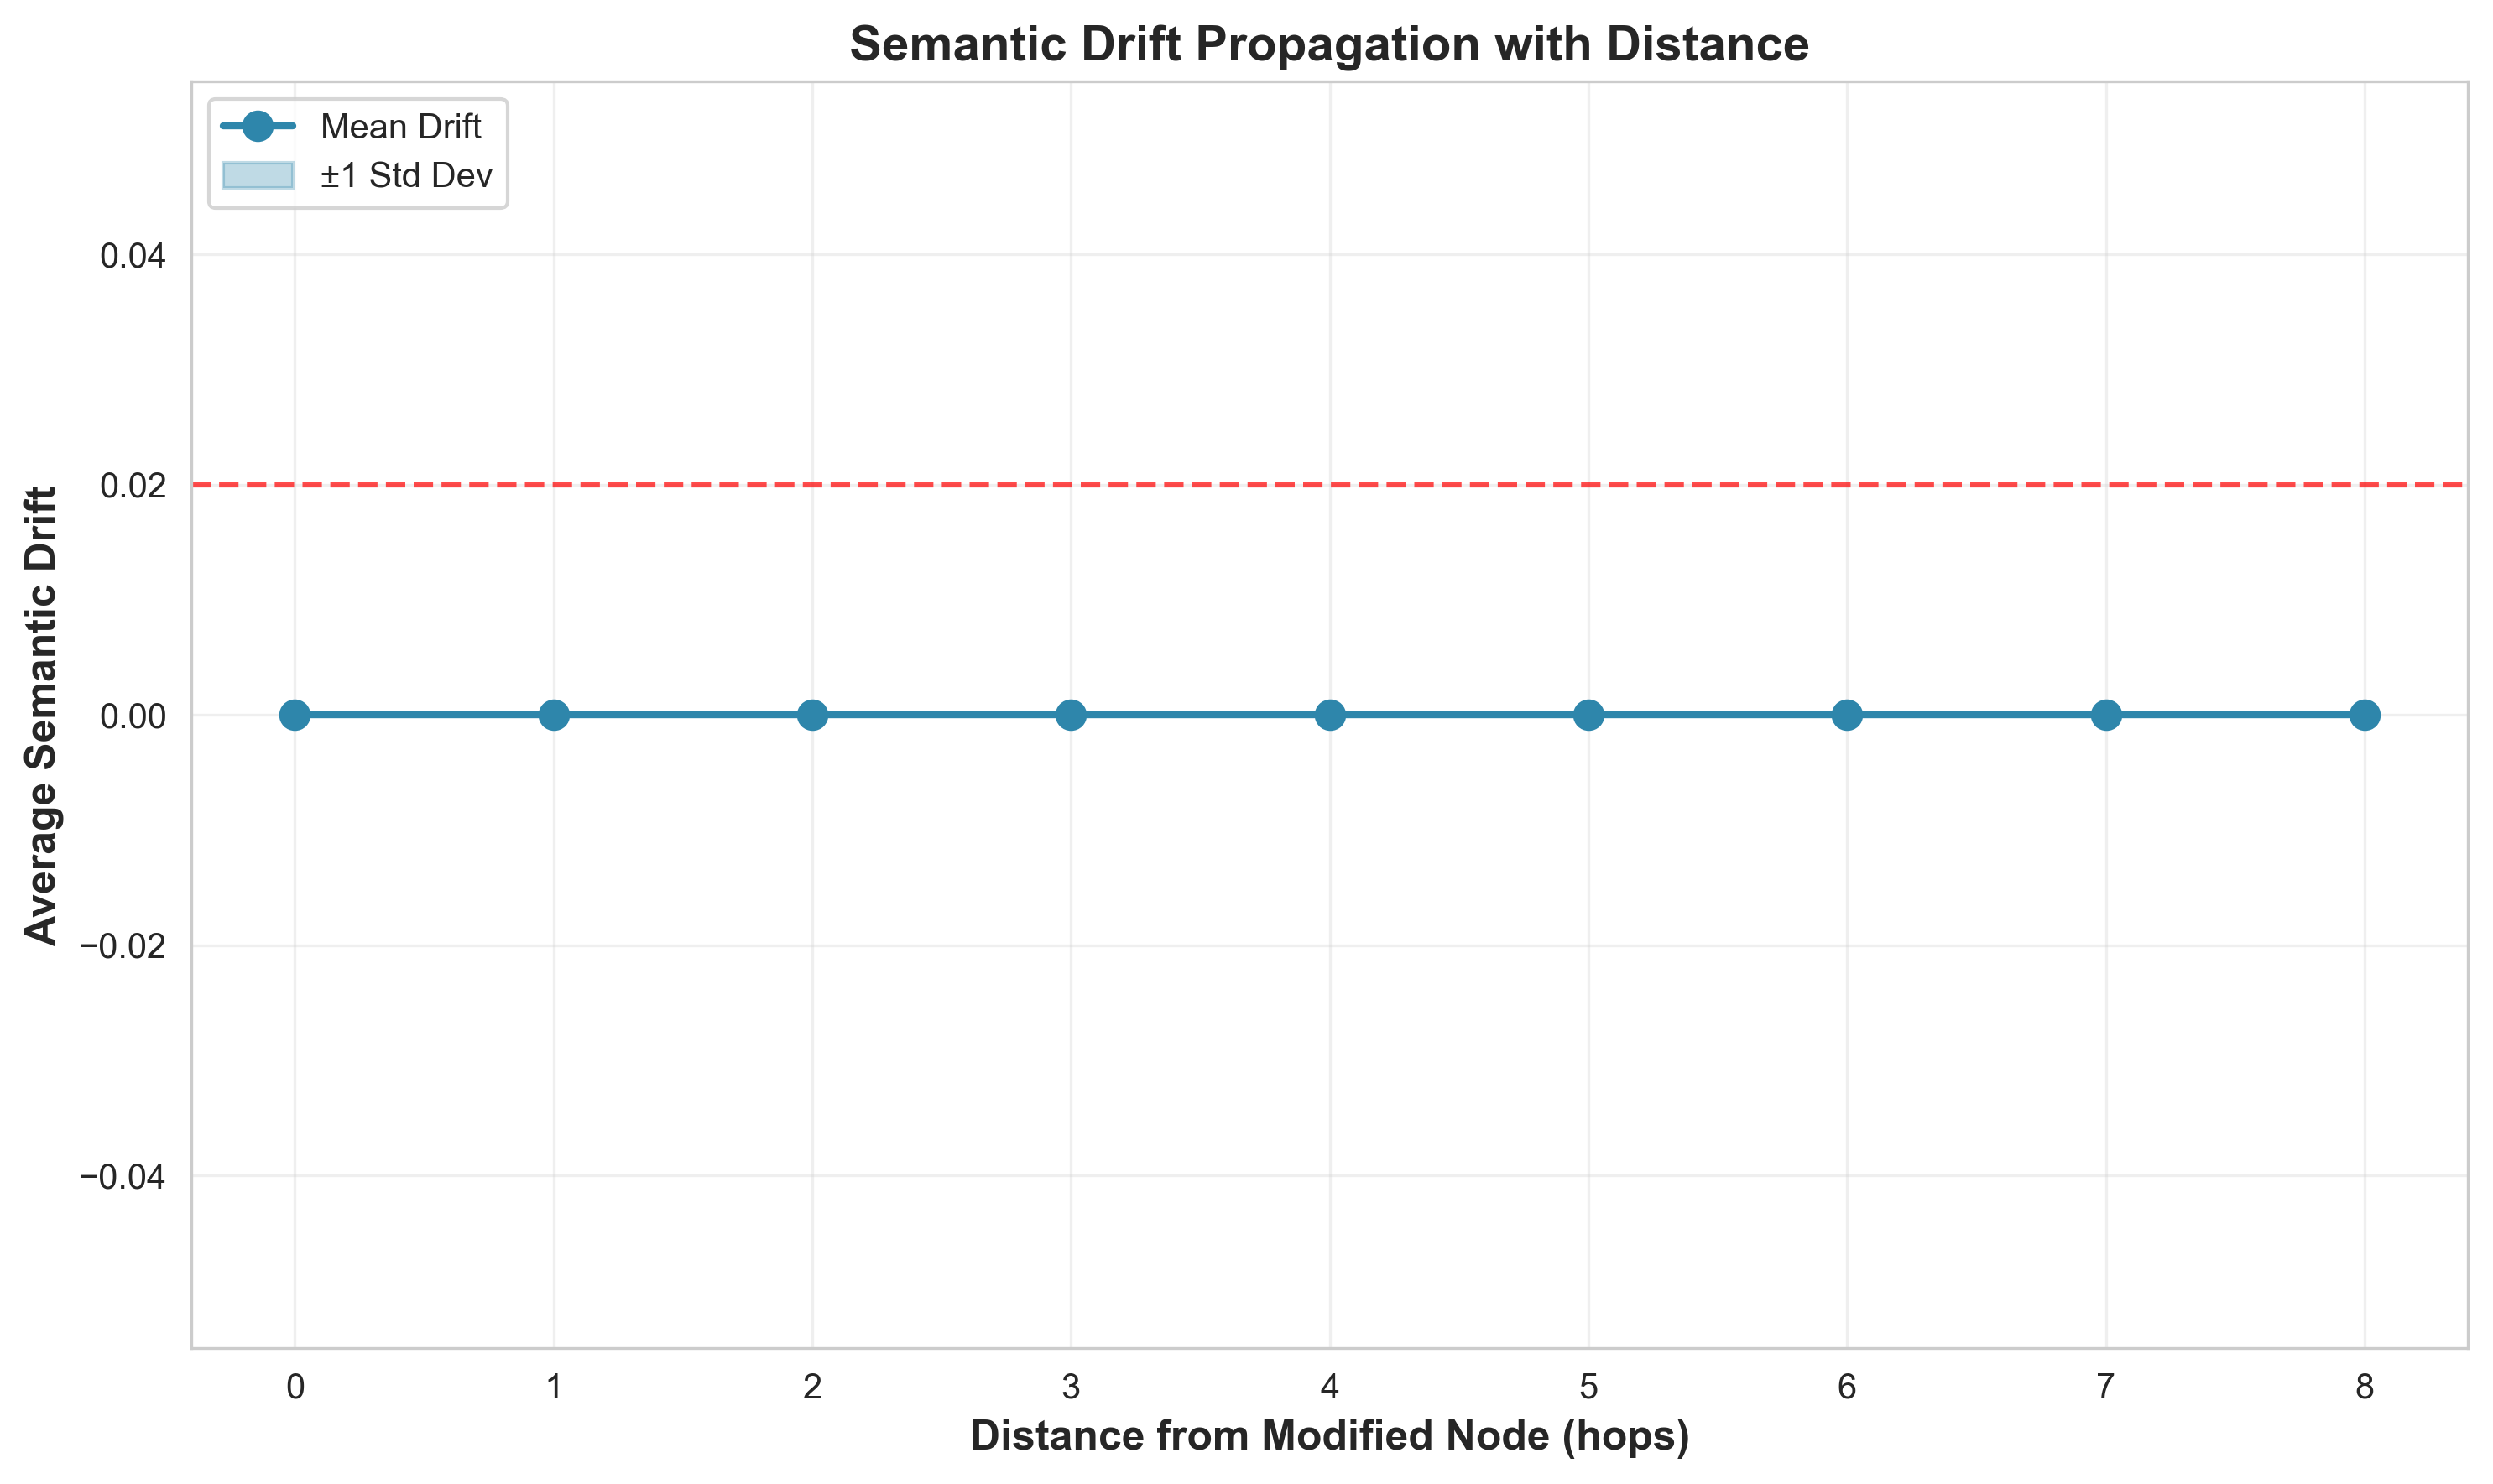

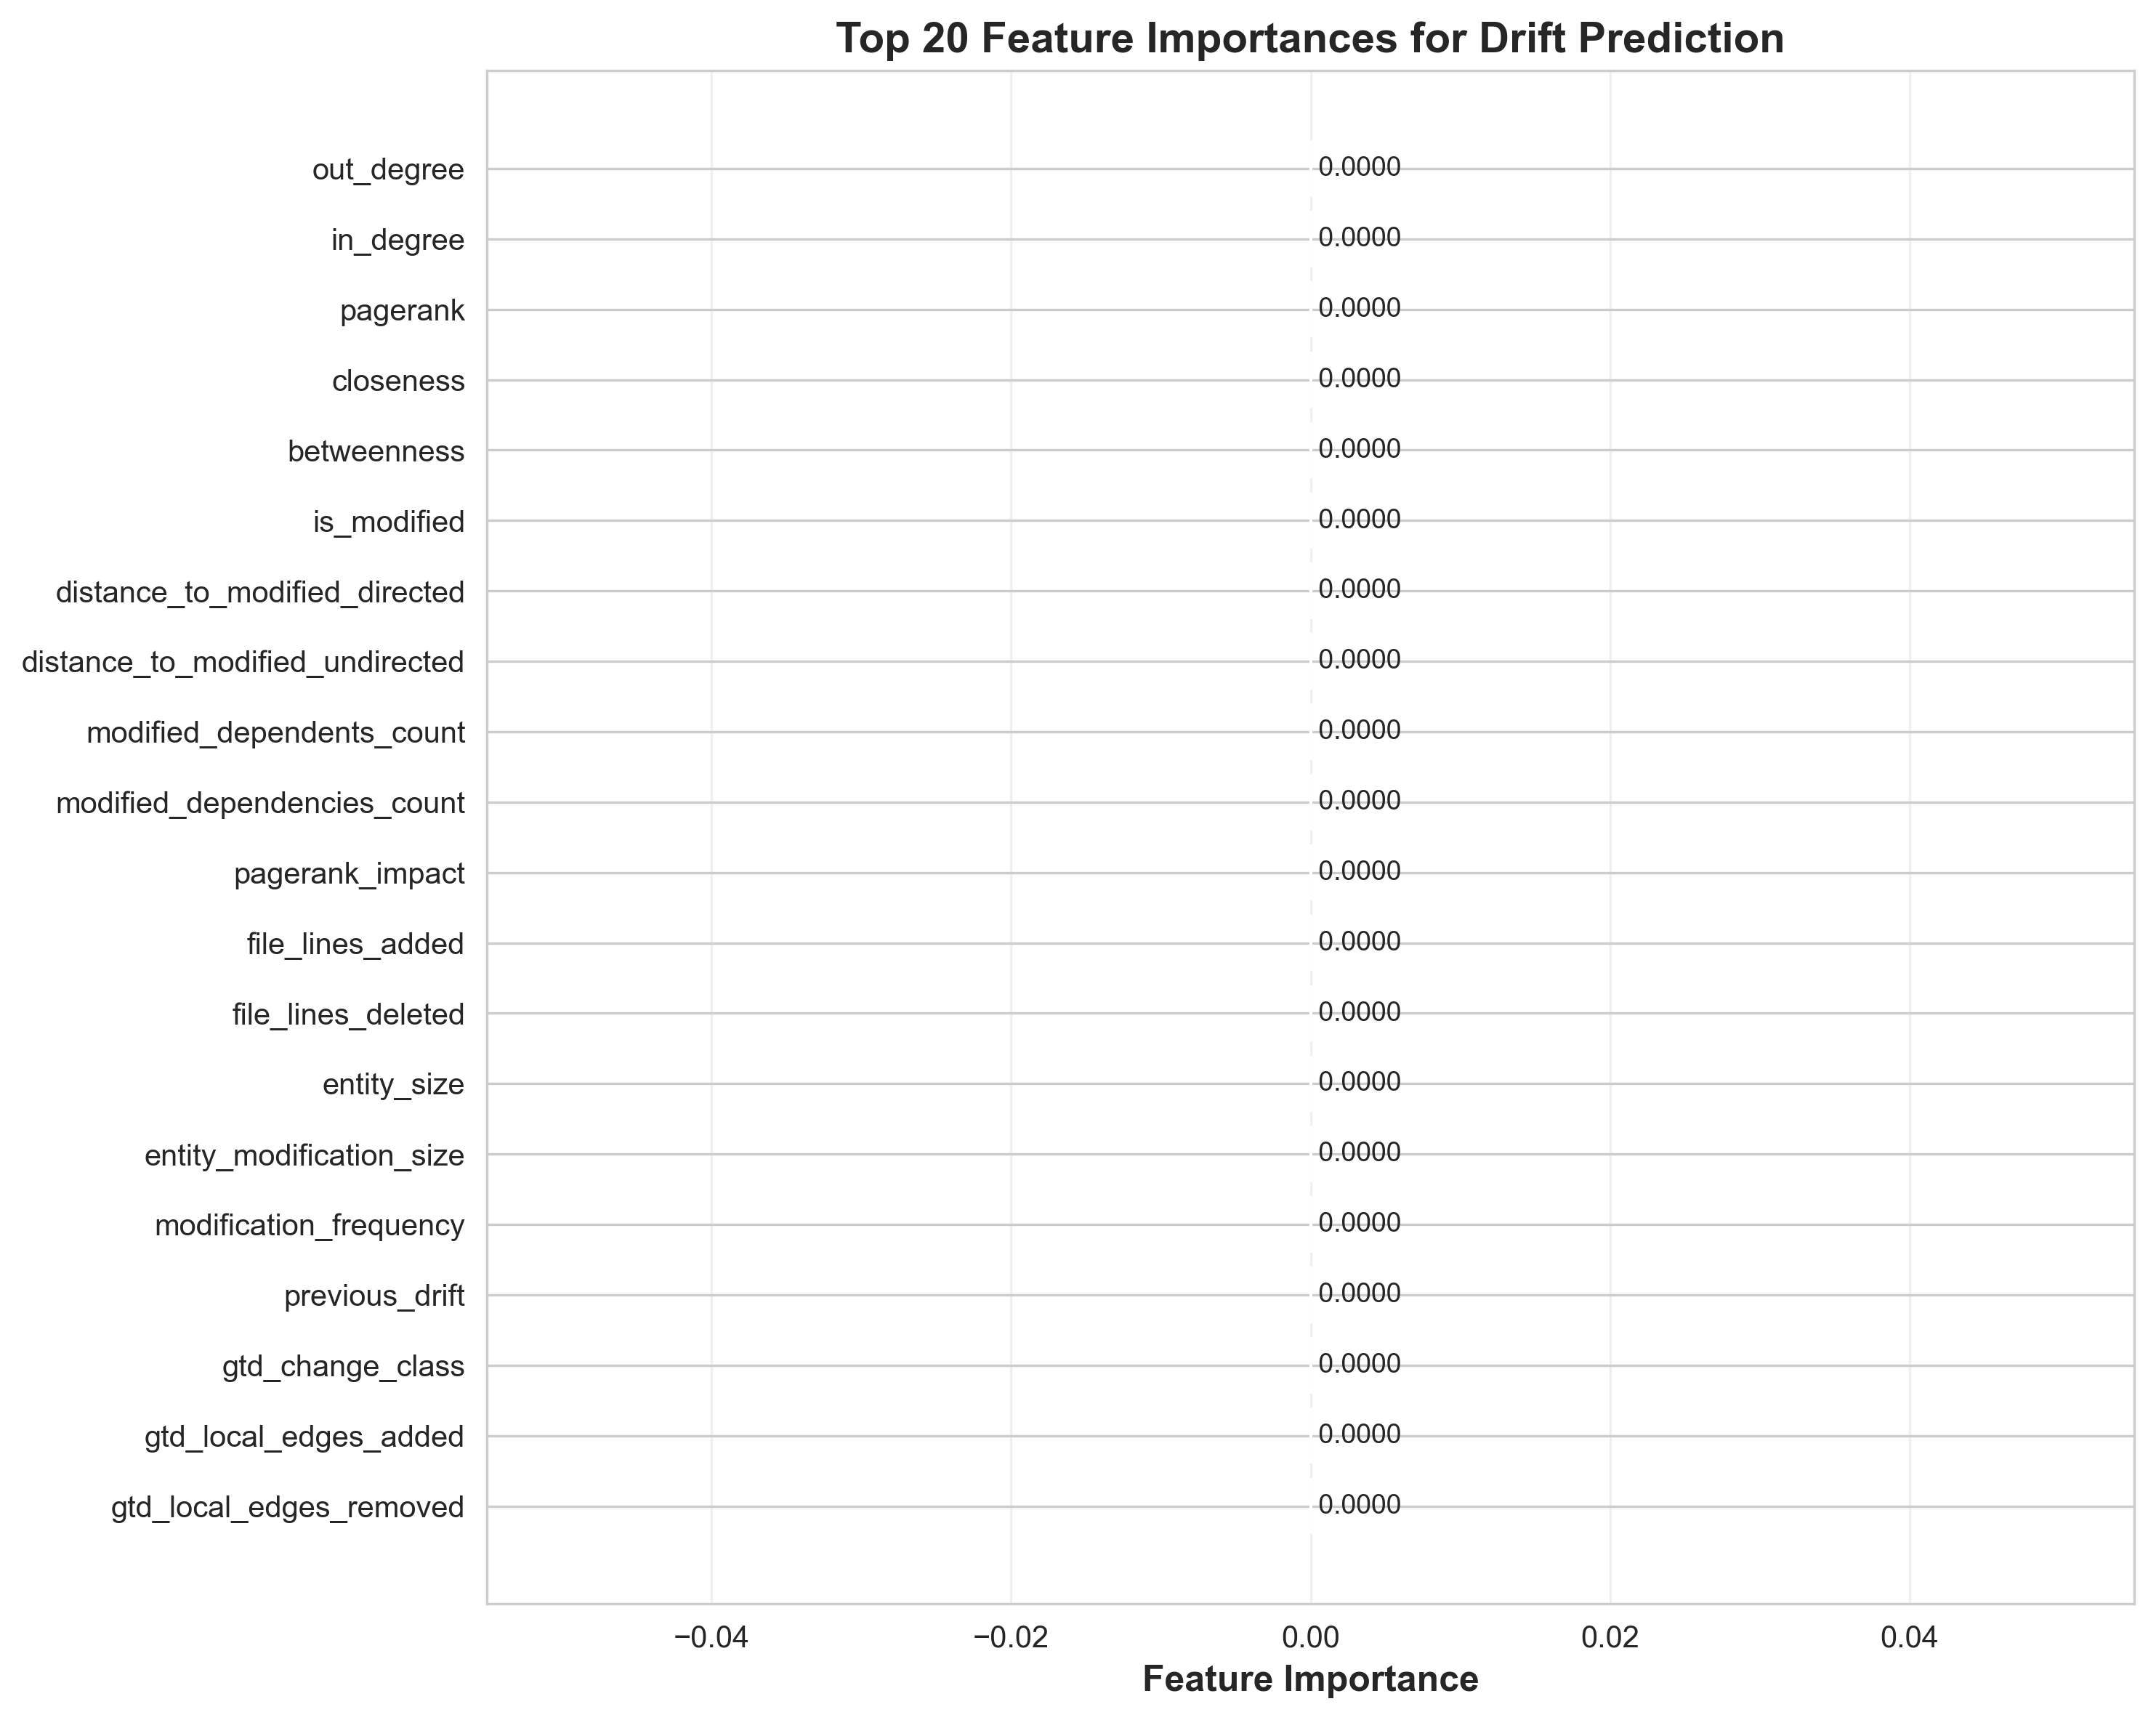

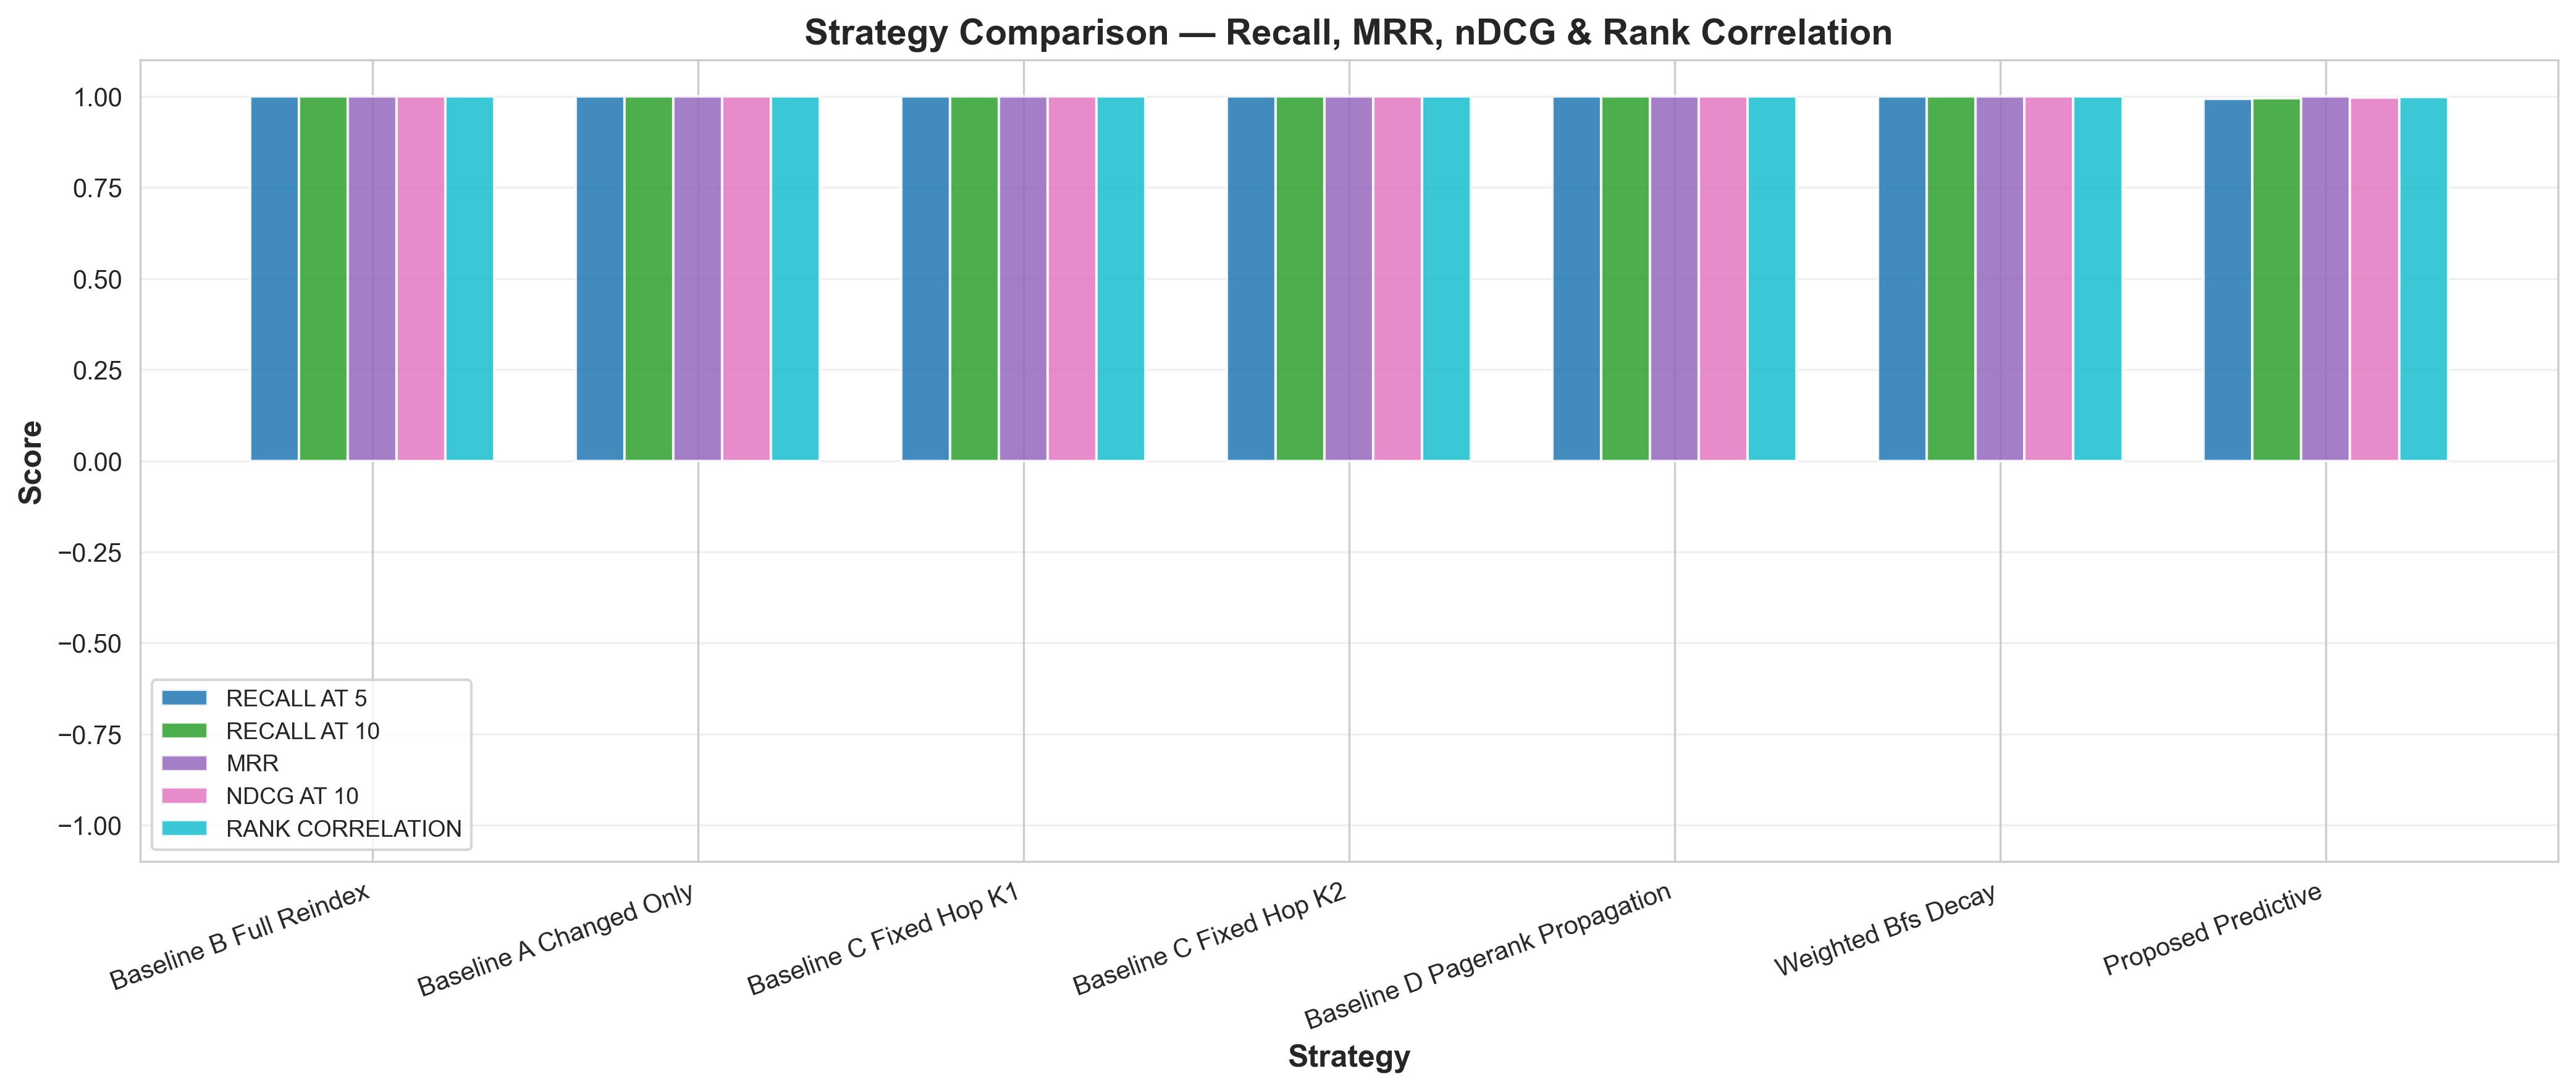

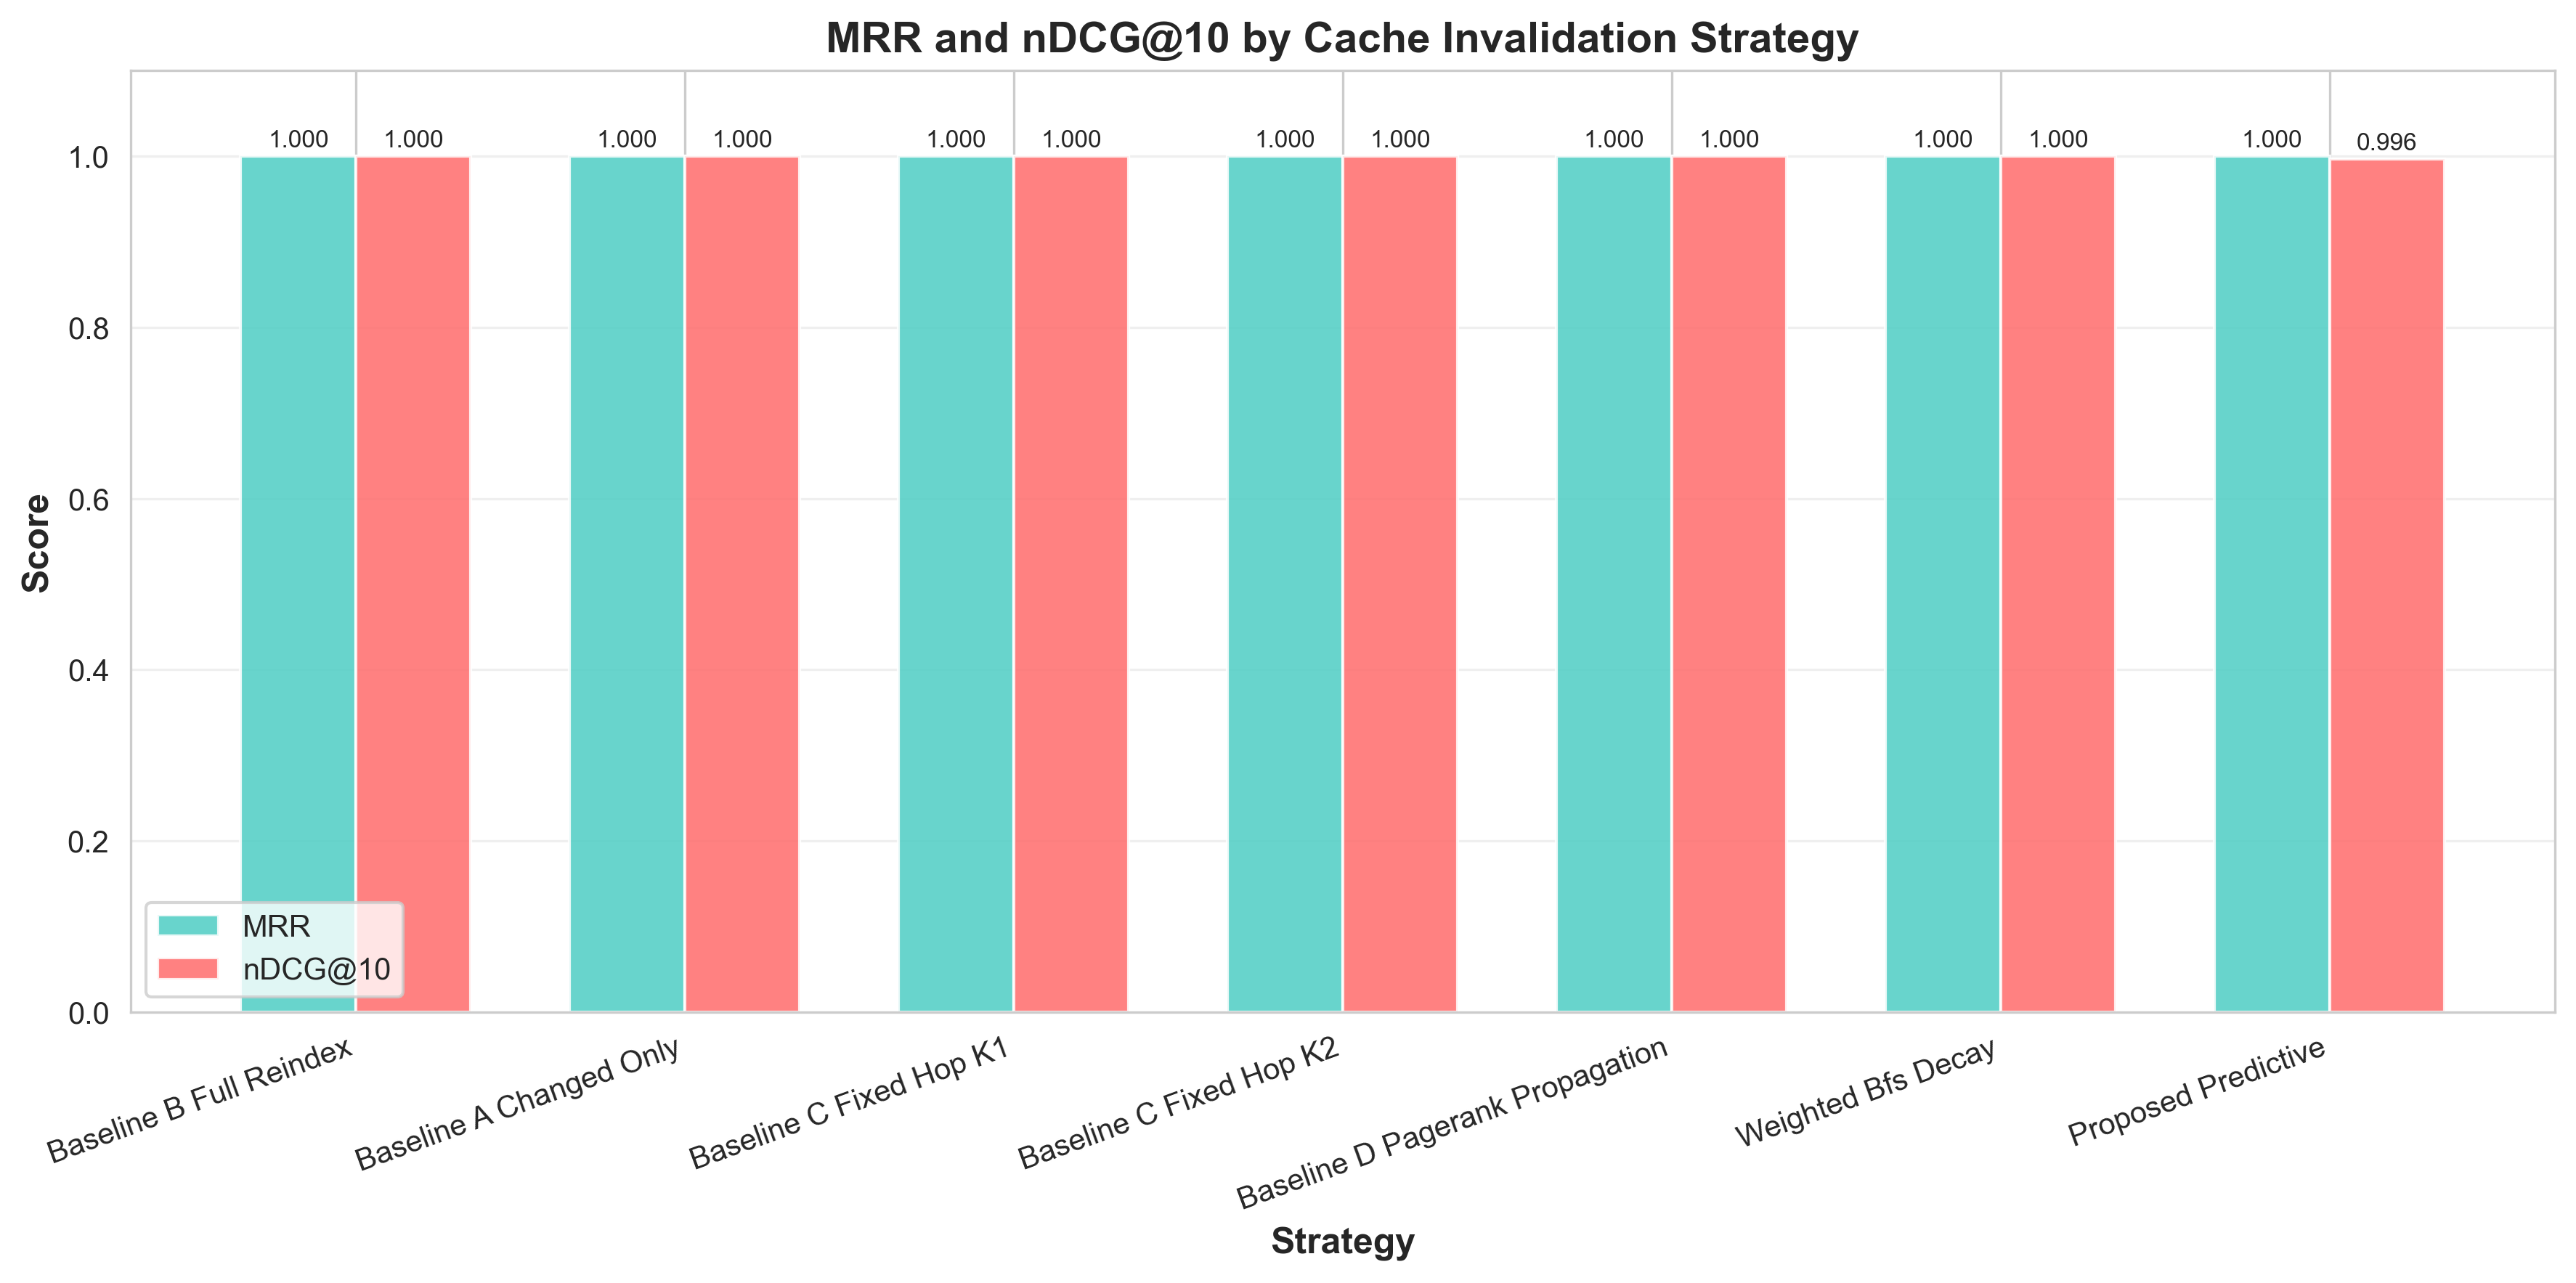

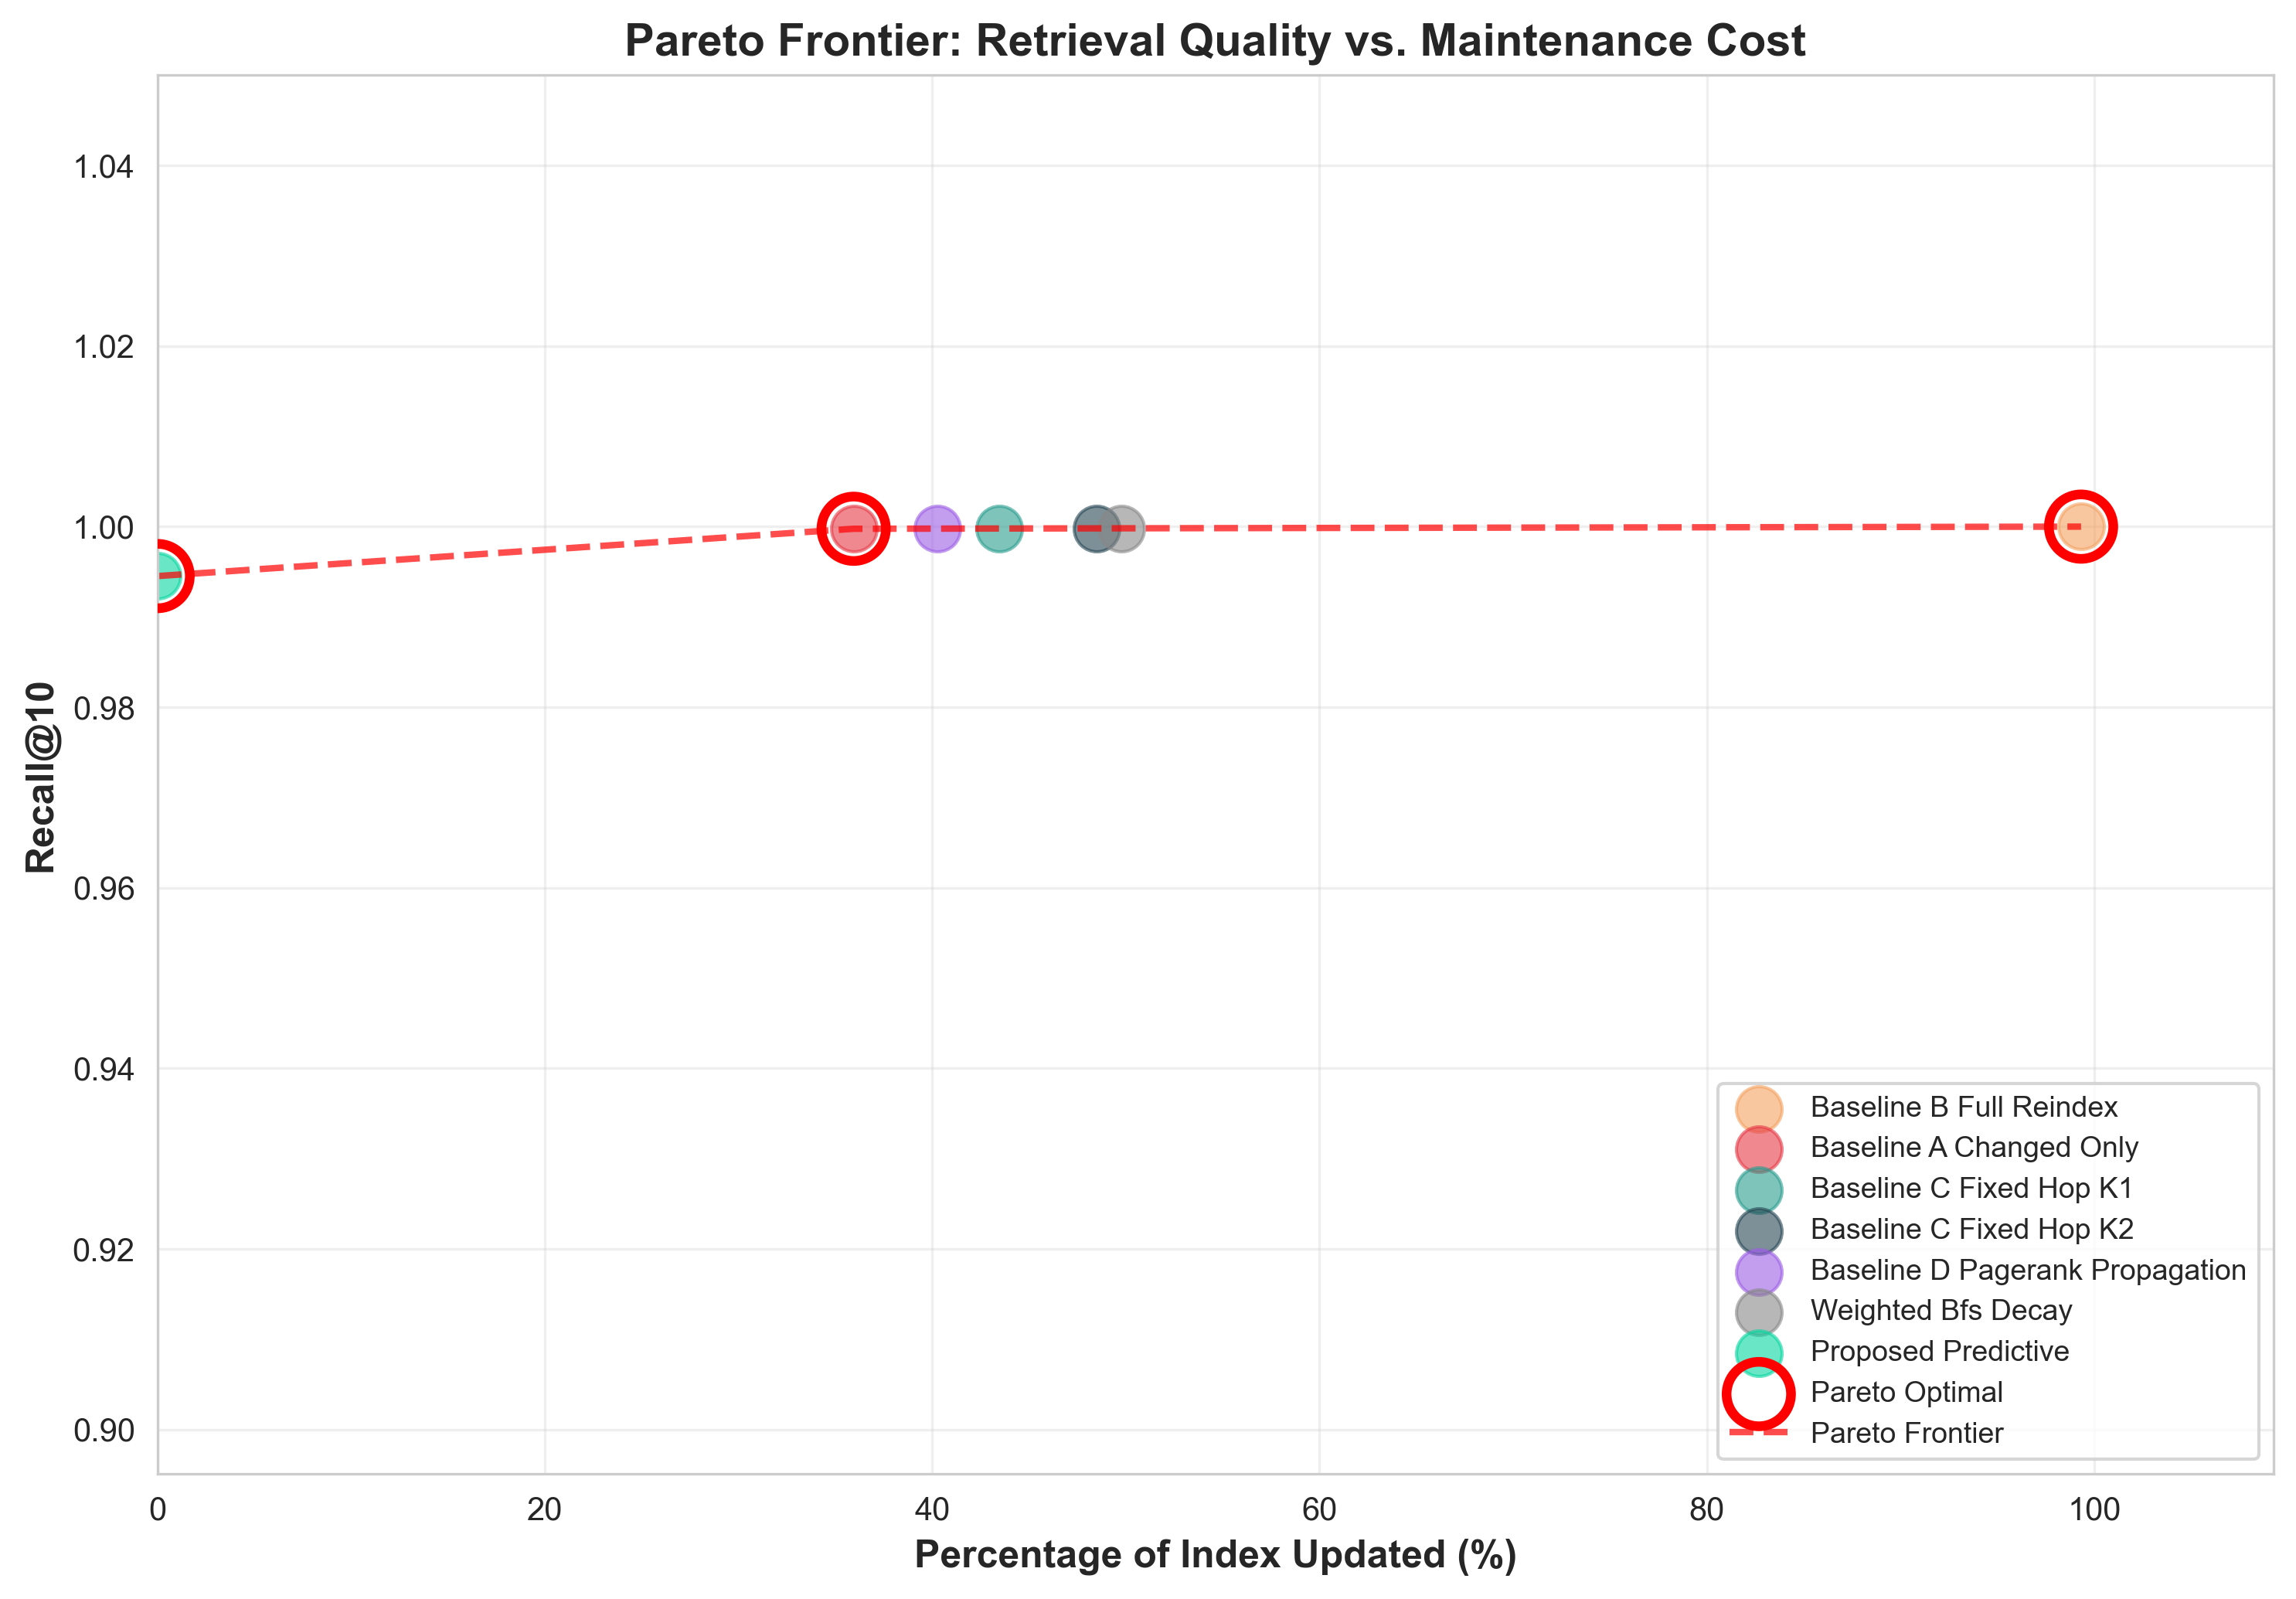

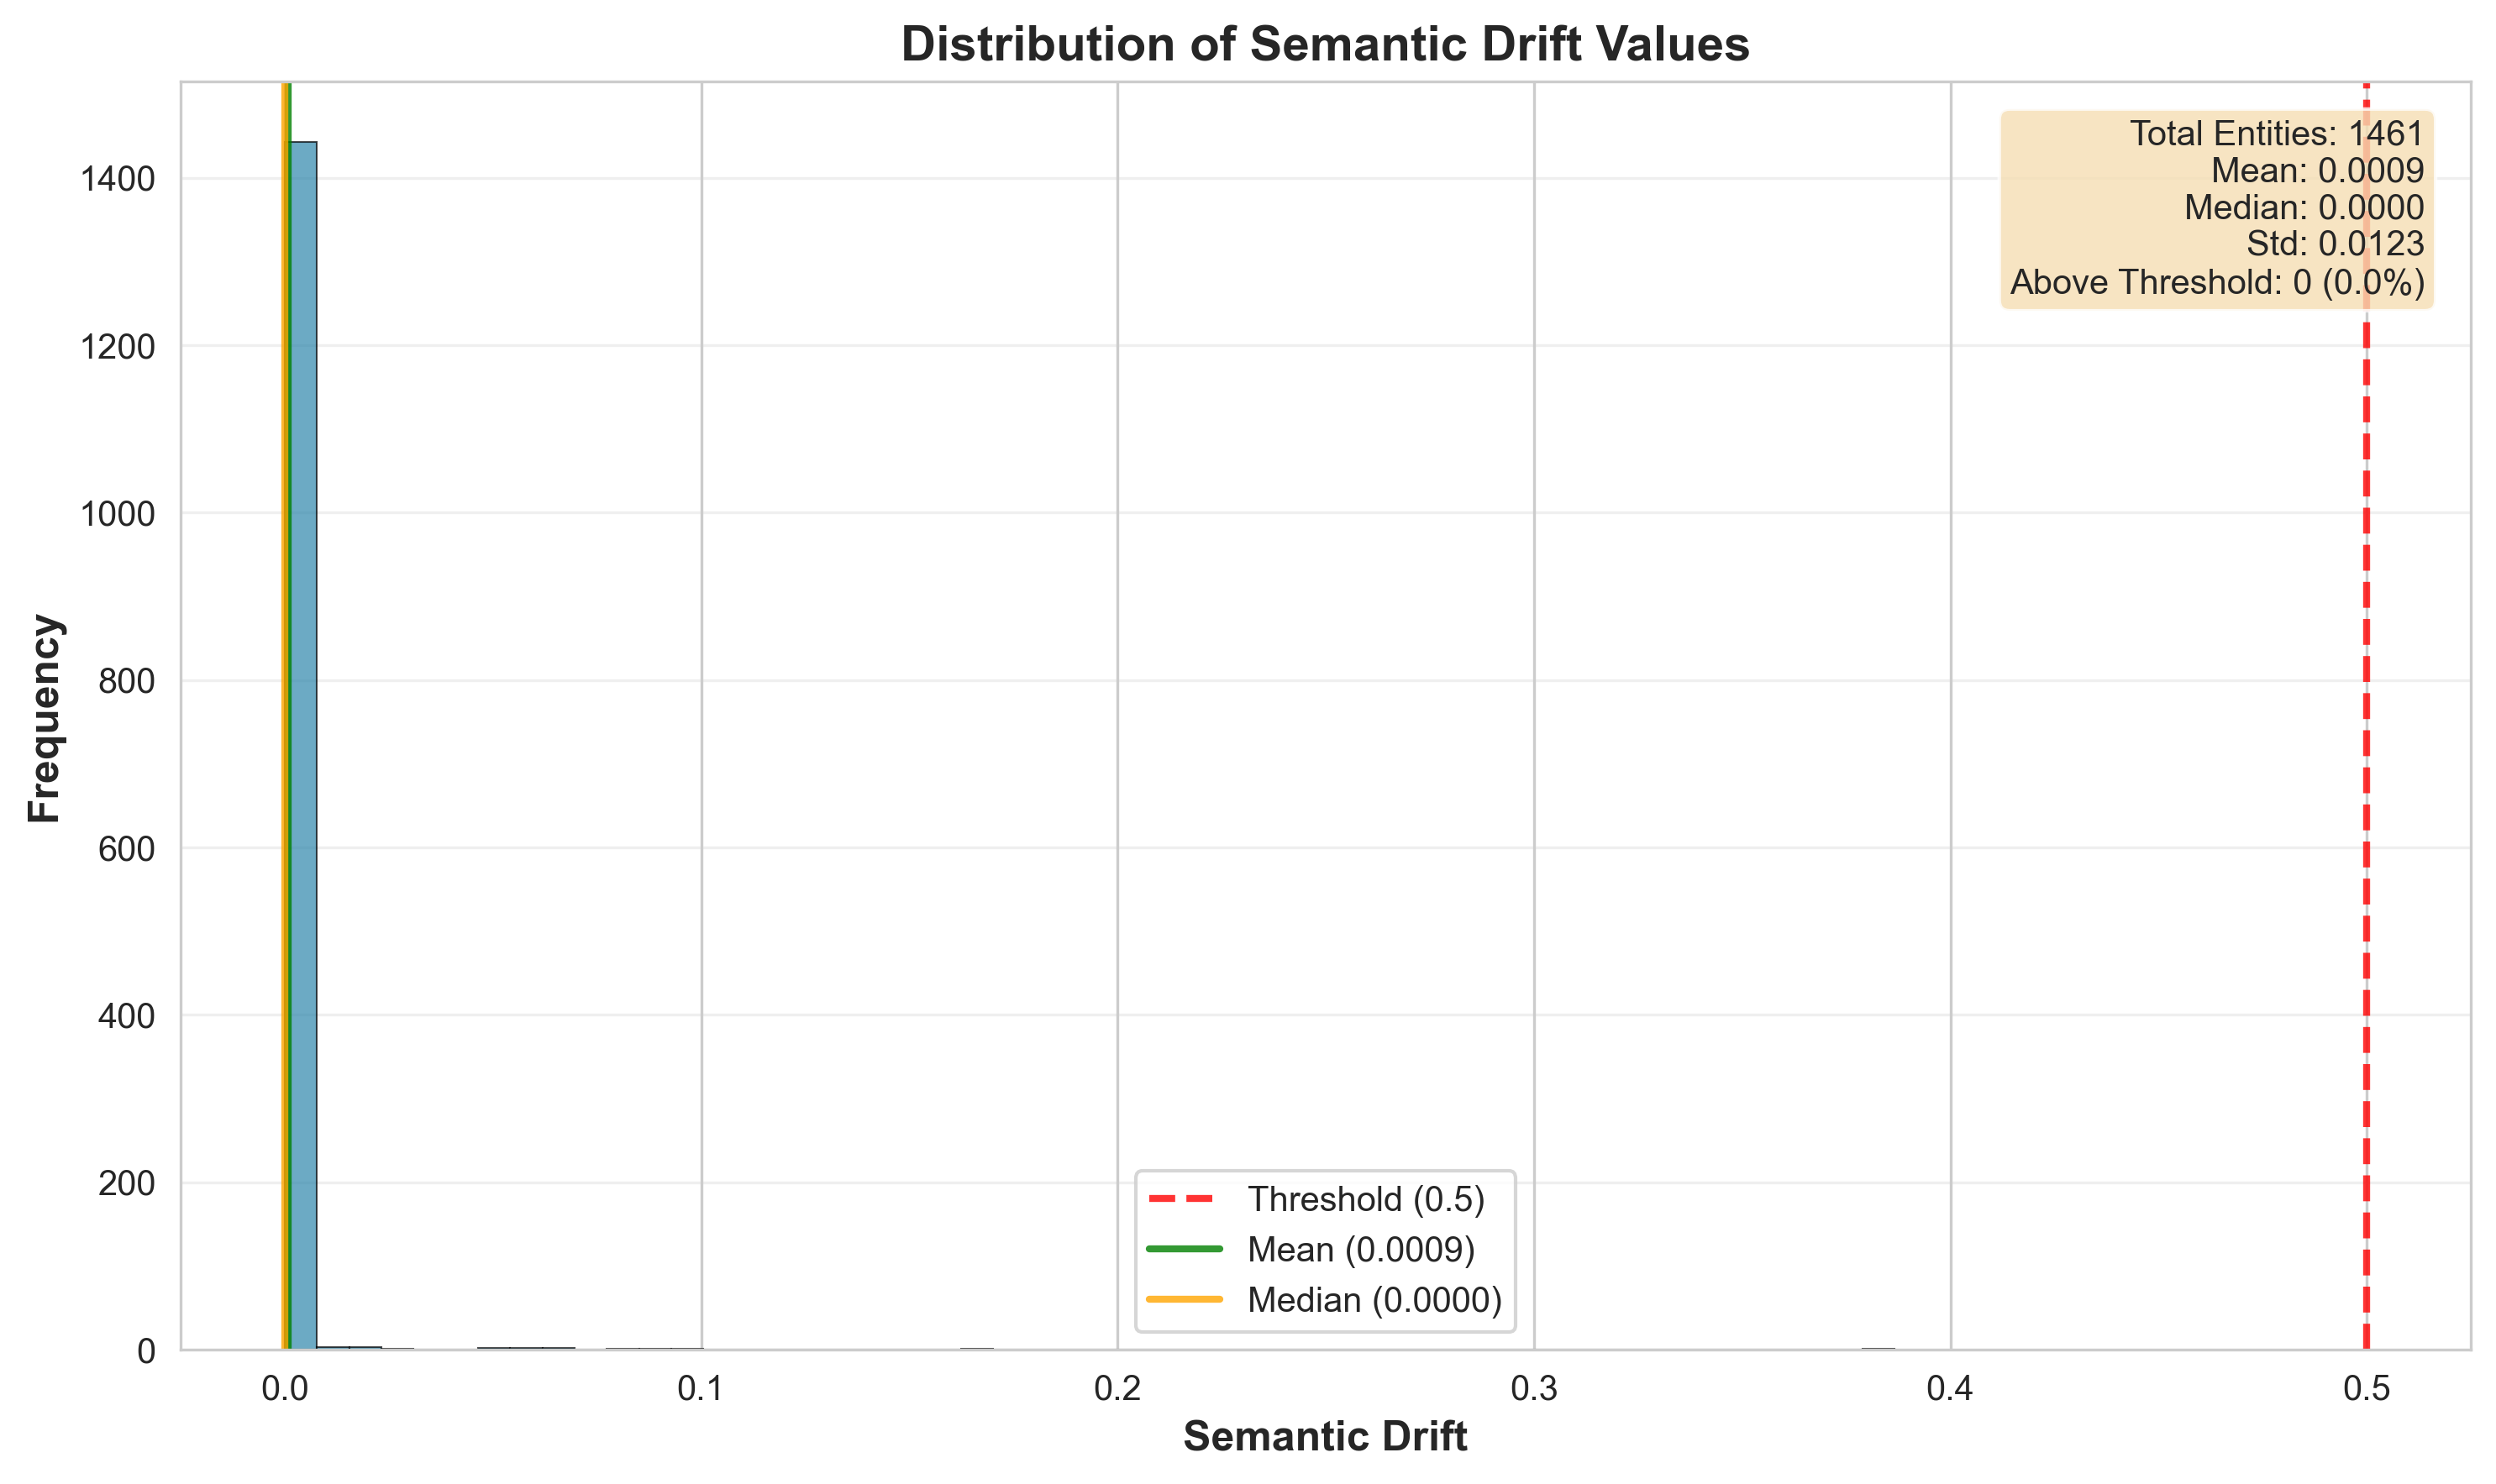

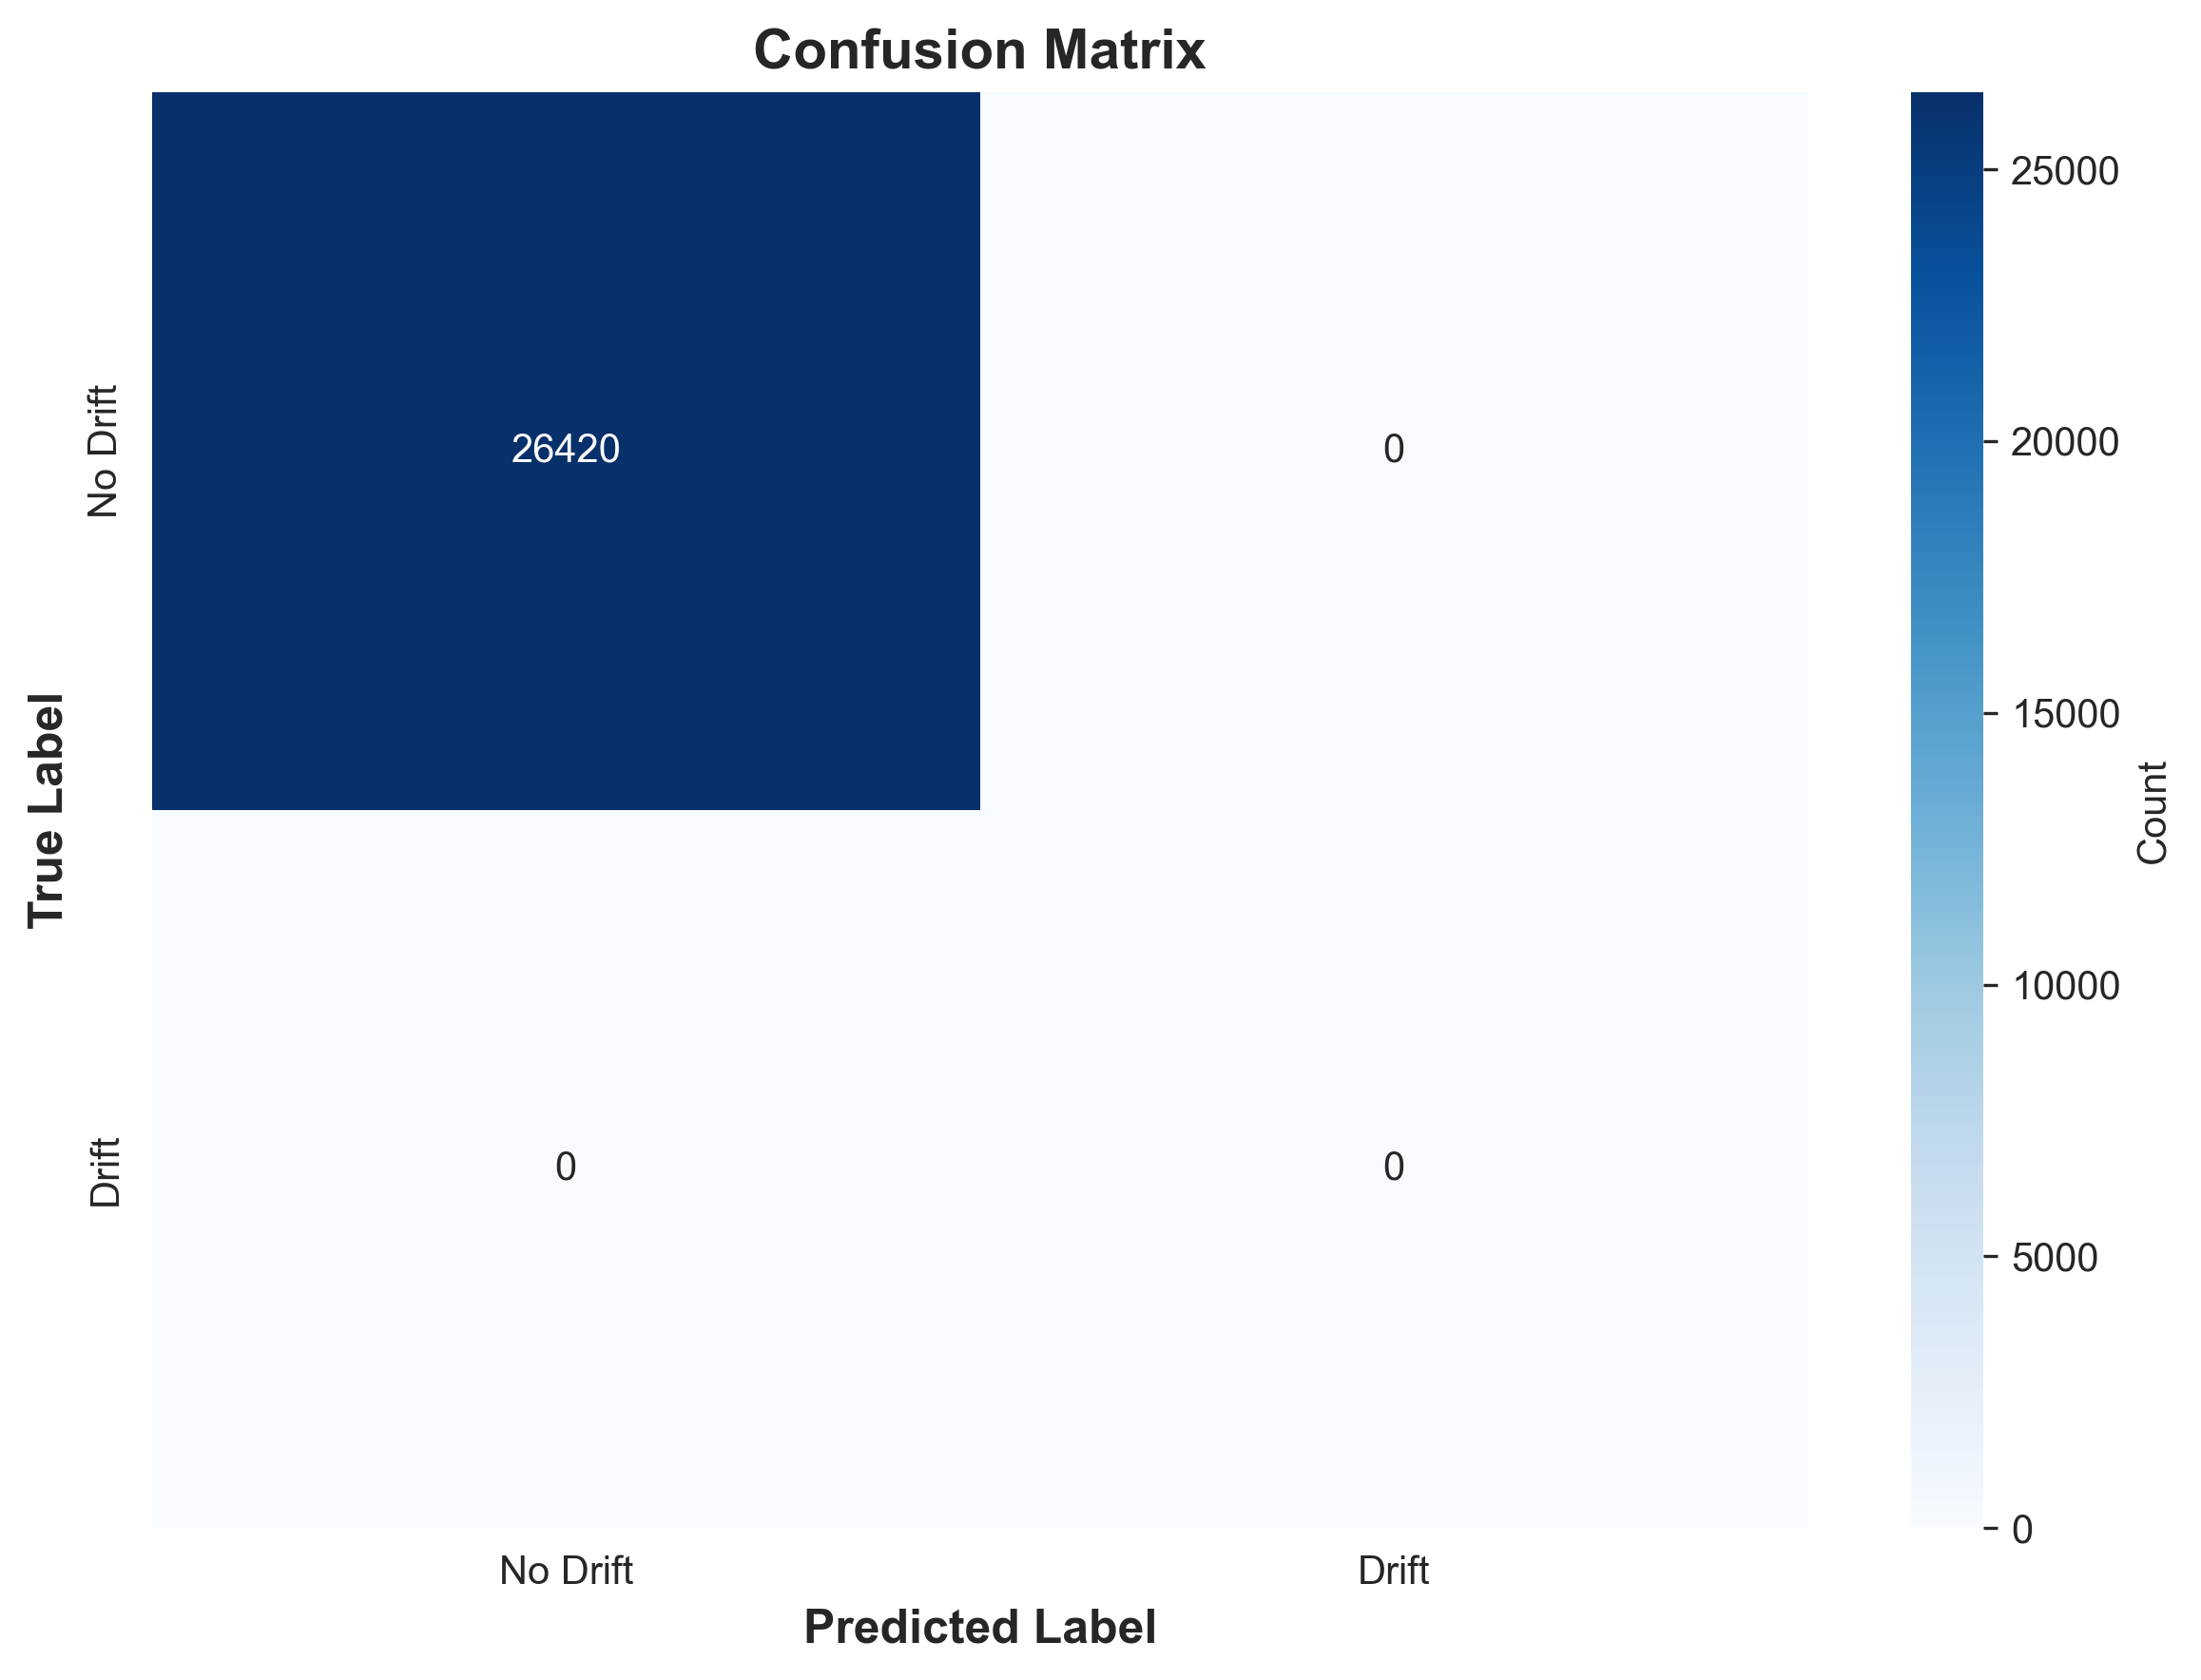

In [11]:
from IPython.display import Image, display

def show_plot(path: str):
    display(Image(filename=path))


results_for_viz = {
    "strategy_results": {name: row.to_dict() for name, row in averaged_results.iterrows()},
    "drift_by_distance": drift_by_distance,
}
feature_importance = predictor.get_feature_importance()

with timed("6_visualize", "plots"):
    plot_paths = []

    if drift_by_distance:
        plot_paths.append(visualizer.plot_drift_decay(drift_by_distance))

    if feature_importance:
        plot_paths.append(visualizer.plot_feature_importance(feature_importance))

    if results_for_viz["strategy_results"]:
        plot_paths.append(visualizer.plot_strategy_comparison(results_for_viz["strategy_results"]))
        plot_paths.append(visualizer.plot_ranking_metrics(results_for_viz["strategy_results"]))

        pareto_df = evaluator.compute_pareto_frontier(results_for_viz["strategy_results"],
                                                       recall_metric=PRIMARY_RECALL_COL)
        cost_df = evaluator.compute_maintenance_cost(results_for_viz["strategy_results"])
        cost_df = cost_df.merge(
            pd.DataFrame([{"strategy": k, "recall": v.get(PRIMARY_RECALL_COL, 0)}
                          for k, v in results_for_viz["strategy_results"].items()]),
            on="strategy",
        )
        plot_paths.append(visualizer.plot_pareto_frontier(pareto_df, cost_df))
    else:
        print("No strategy results to plot (see the too-few-test-commits note above).")

    all_drifts_flat = {}
    for d in drifts_history.values():
        all_drifts_flat.update(d)
    if all_drifts_flat:
        plot_paths.append(visualizer.plot_drift_distribution(all_drifts_flat, threshold))

    if all_predictions and all_true_labels:
        plot_paths.append(visualizer.plot_confusion_matrix(np.array(all_true_labels), np.array(all_predictions)))

for p in plot_paths:
    show_plot(p)

In [12]:
with timed("6_visualize", "summary_report"):
    report_path = visualizer.generate_summary_report({
        "feature_importance": feature_importance or {},
        "strategy_results": results_for_viz["strategy_results"],
    })

print(Path(report_path).read_text())
print(f"\nAll plots + summary report saved under: {results_dir}")

PREDICTIVE SEMANTIC CACHE INVALIDATION - EXPERIMENT SUMMARY

TOP 10 FEATURE IMPORTANCES
--------------------------------------------------------------------------------
1. out_degree: 0.0000
2. in_degree: 0.0000
3. pagerank: 0.0000
4. closeness: 0.0000
5. betweenness: 0.0000
6. is_modified: 0.0000
7. distance_to_modified_directed: 0.0000
8. distance_to_modified_undirected: 0.0000
9. modified_dependents_count: 0.0000
10. modified_dependencies_count: 0.0000

STRATEGY COMPARISON
--------------------------------------------------------------------------------

BASELINE_B_FULL_REINDEX
  Entities Updated: 629.047619047619 / 633.2857142857143 (99.33%)
  Recall@5:          1.0000
  Recall@10:         1.0000
  MRR:               1.0000
  nDCG@10:           1.0000
  Rank Correlation:  1.0000
  Evaluation Time:   0.0000s

BASELINE_A_CHANGED_ONLY
  Entities Updated: 228.5952380952381 / 633.2857142857143 (35.94%)
  Recall@5:          0.9998
  Recall@10:         0.9998
  MRR:               1.0000
  

## Timing summary

Everything timed above, broken down by stage and sub-step, sorted by total
time descending — this is what to look at to see where the pipeline actually
spends its time.

In [13]:
by_stage = timing_table(group_cols=("stage",))
by_stage

,stage,calls,total_seconds,mean_seconds
0,2_parse_embed,564,2572.113730,4.560485
1,3_drift_features,701,224.410144,0.320129
2,5_evaluate,378,80.507854,0.212984
3,0_setup,3,14.387557,4.795852
4,6_visualize,2,9.228542,4.614271
5,4_train,5,2.023415,0.404683
6,1_harvest,1,0.101837,0.101837


In [14]:
by_substage = timing_table(group_cols=("stage", "substage"))
by_substage

,stage,substage,calls,total_seconds,mean_seconds
0,2_parse_embed,parse,141,1621.192593,11.497820
1,2_parse_embed,embed,141,910.086192,6.454512
2,3_drift_features,leave_one_out_ground_truth,140,96.121090,0.686579
3,3_drift_features,modified_entities,140,88.376183,0.631258
4,5_evaluate,generate_queries,42,34.335235,0.817506
5,2_parse_embed,checkout,141,31.519958,0.223546
6,3_drift_features,extract_features,140,27.881028,0.199150
7,0_setup,load_ground_truth_queries,1,14.154104,14.154104
8,3_drift_features,gtd,140,11.517997,0.082271
9,2_parse_embed,rsd_add_commit,141,9.314987,0.066064


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_stage["stage"][::-1], by_stage["total_seconds"][::-1])
ax.set_xlabel("Total seconds")
ax.set_title("Time per pipeline stage")
plt.tight_layout()
plt.show()

grand_total = sum(t["seconds"] for t in TIMINGS)
print(f"\nTotal measured wall-clock time: {grand_total:.2f}s ({grand_total/60:.1f} min)")


Total measured wall-clock time: 2902.77s (48.4 min)
